In [1]:
using PowerDynamics
using PowerDynamics: Library
using PowerDynamics.Library.ComposableInverter: SimpleGFLDC
using OrdinaryDiffEqRosenbrock
using OrdinaryDiffEqNonlinearSolve
using CairoMakie
using Graphs
using GraphPlot
using ModelingToolkit
using Accessors
using AccessorsExtra
using SparseArrays
using Symbolics
using LinearSolve
using DifferentialEquations
using JSON3
using Colors
using Plots
using Serialization
using Statistics

In [74]:
data = JSON3.read(read("names.json", String))
sol1 = deserialize("sim/cincreaseSlowFROM85Comm.jld2")
println("finished")

finished


In [75]:
data = JSON3.read(read("names.json", String))
sol2 = deserialize("sim/cincreaseSlowFROM85Ind.jld2")
println("finished")

finished


In [76]:
data = JSON3.read(read("names.json", String))
sol3 = deserialize("sim/cincreaseSlowFROM85Res.jld2")
println("finished")

finished


In [37]:
data = JSON3.read(read("names.json", String))
sol4 = deserialize("sim/aashort.jld2")
println("finished")

finished


In [38]:
let
    fig = Figure(size = (800, 500))
    ax = Axis(fig[1, 1], title = "", xlabel = "t (s)", ylabel = "P (GW)")

    total1 = zeros(length(sol2.t))
    total2 = zeros(length(sol2.t))
    total3 = zeros(length(sol2.t))
    total4 = zeros(length(sol2.t))
    ref = zeros(length(sol2.t))
    
    for name in data.nodes     
        parts = split(string(name), "_")

        if length(parts) != 2
            continue
        end

        if parts[2] == "load"
            total1 .-= sol1(sol2.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end
 
        if parts[2] == "load"
            total2 .-= sol2(sol2.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end

        if parts[2] == "load"
            total3 .-= sol3(sol2.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end

        if parts[2] == "load"
            total4 .-= sol4(sol2.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end

        if parts[2] == "load"
            ref .-= sol4(sol2.t, idxs=VIndex(Symbol(name), :load₊Pset)).u
        end
    end

    lines!(ax, sol2.t, total1, color = :firebrick,   linewidth = 2.5, label = "Komercja")
    lines!(ax, sol2.t, total2, color = :steelblue,   linewidth = 2.5, label = "Przemysł")
    lines!(ax, sol2.t, total3, color = :goldenrod,   linewidth = 2.5, label = "Obszar mieszkalny")
    lines!(ax, sol2.t, total4, color = :forestgreen, linewidth = 2.5, label = "Rzeczywisty")
    lines!(ax, sol2.t, ref, color = :pink, linewidth = 2.5, label = "Oczekiwany")
    axislegend(ax, position=:lt)

    fig
end

LoadError: UndefVarError: `sol2` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

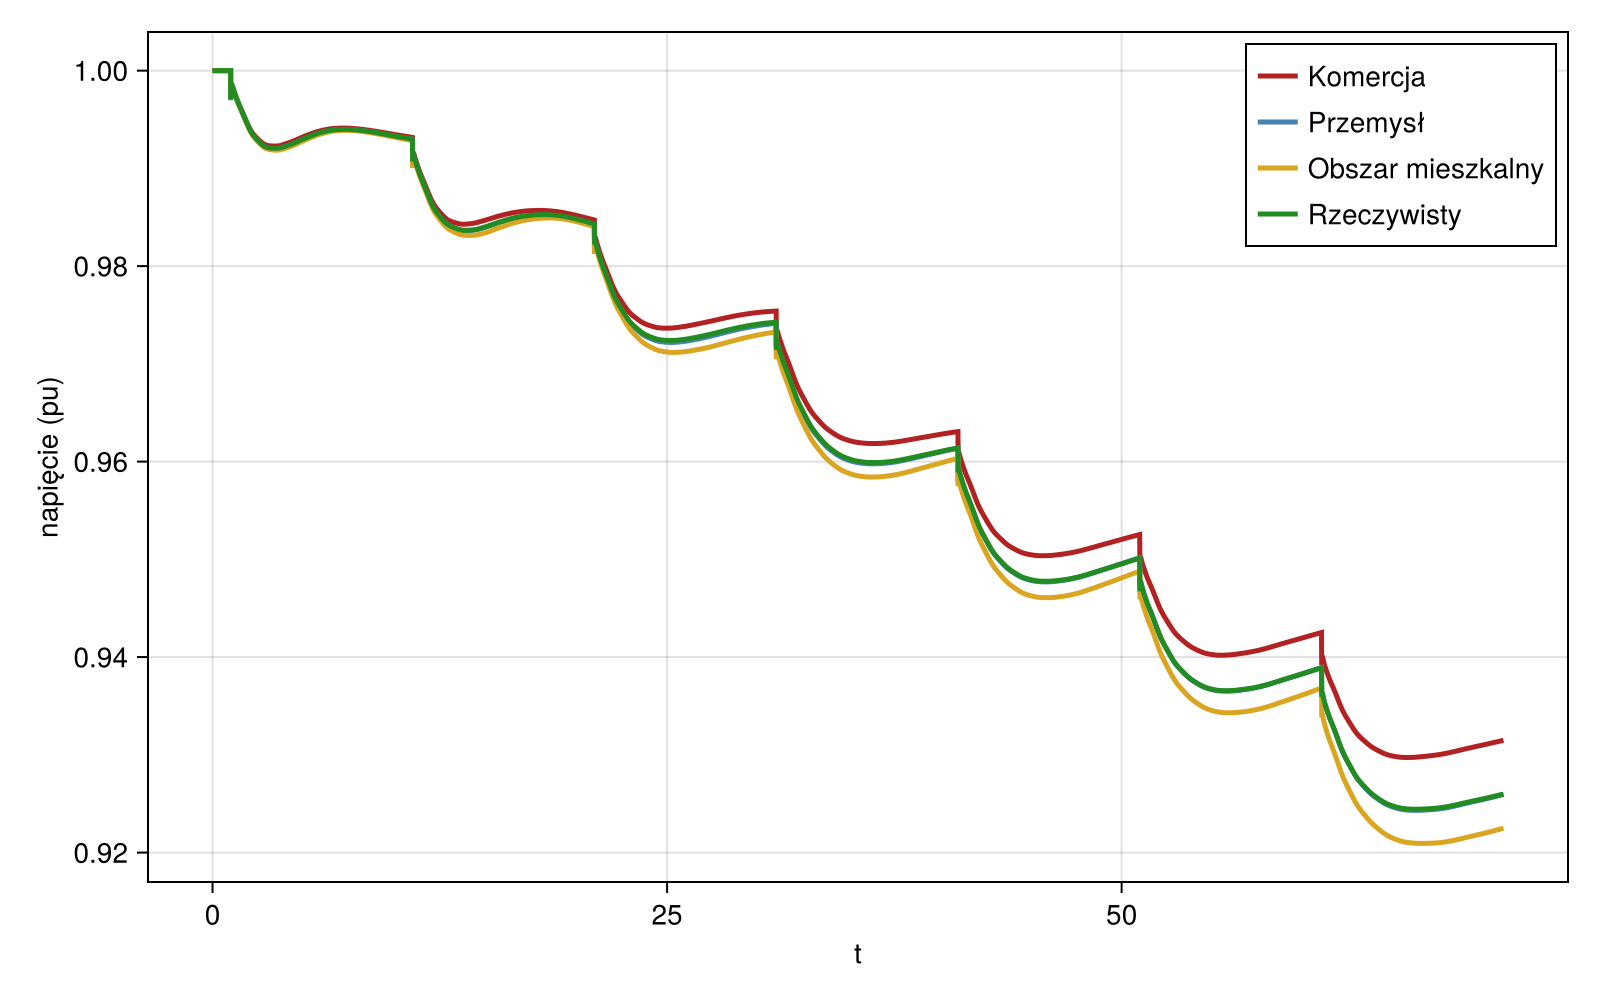

In [104]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="napięcie (pu)")

    lines!(ax, sol1, idxs=EIndex(1, :src₊u_mag ), color = :firebrick,   linewidth = 2.5, label = "Komercja")
    lines!(ax, sol2, idxs=EIndex(1, :src₊u_mag ), color = :steelblue,   linewidth = 2.5, label = "Przemysł")
    lines!(ax, sol3, idxs=EIndex(1, :src₊u_mag ), color = :goldenrod,   linewidth = 2.5, label = "Obszar mieszkalny")
    lines!(ax, sol4, idxs=EIndex(1, :src₊u_mag ), color = :forestgreen, linewidth = 2.5, label = "Rzeczywisty")
    

    # CairoMakie.xlims!(ax, 1.0, 10.0)
    # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
        
    # CairoMakie.xlims!(ax, 0.0, 8.0)
    # CairoMakie.ylims!(ax, 0.8, 1.2)
    axislegend(ax, position=:rt)
    fig
end

In [2]:
data = JSON3.read(read("names.json", String))
sol5 = deserialize("sim/aashort.jld2")
println("finished")

finished


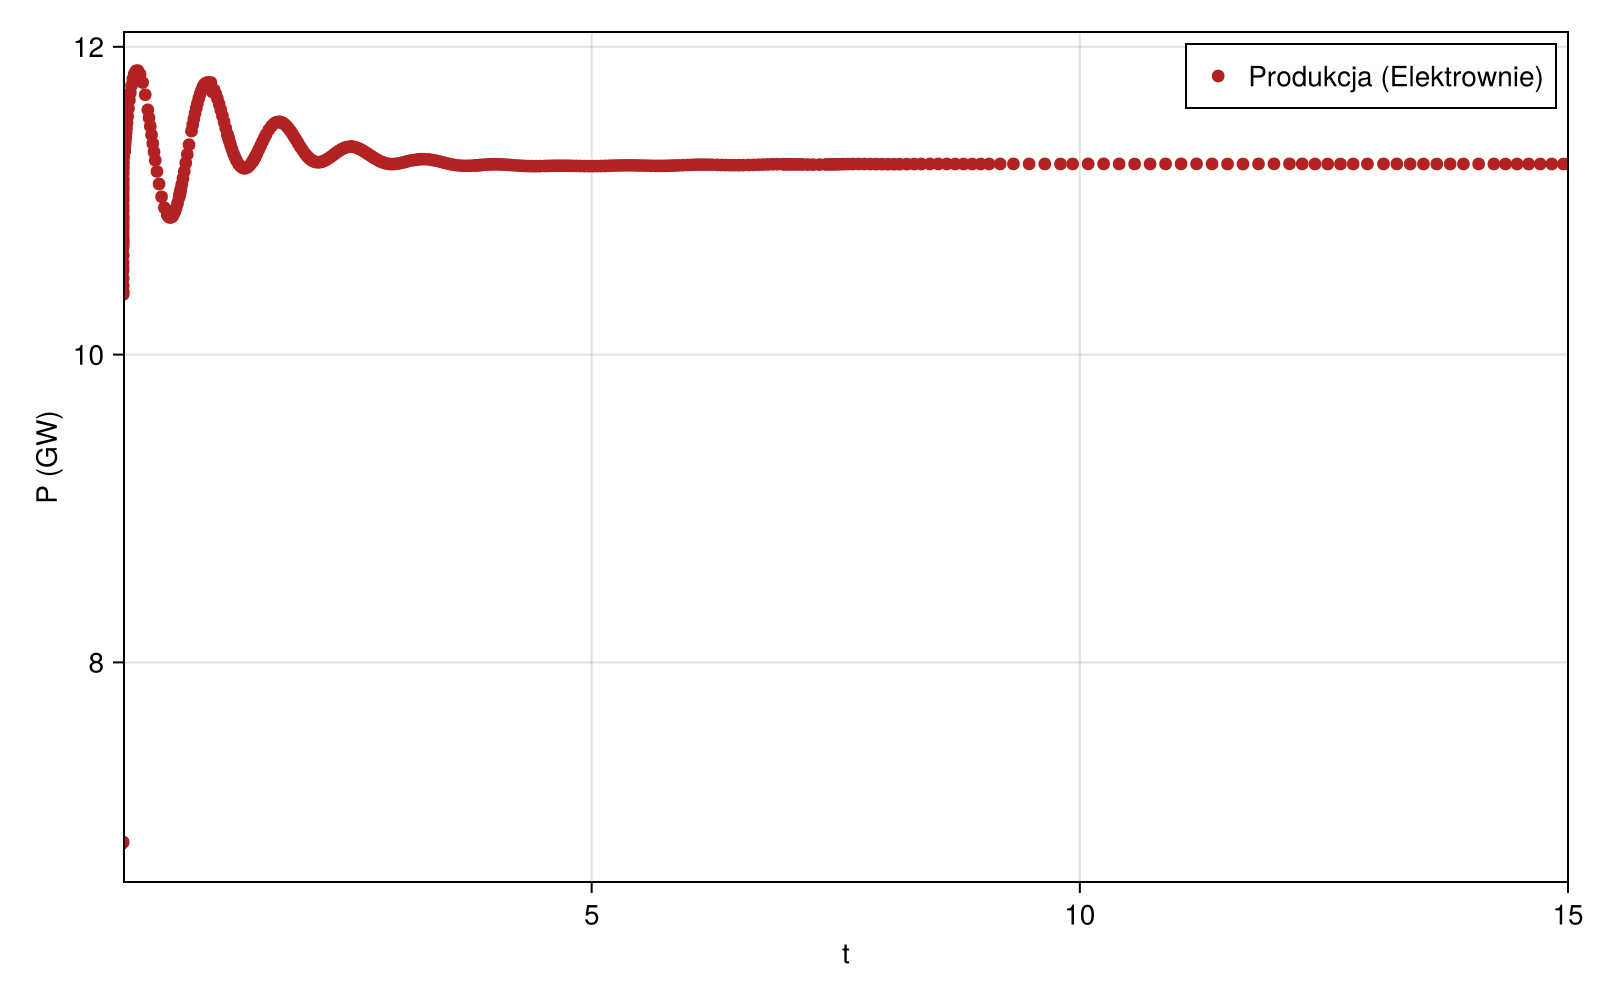

In [14]:
let
    fig = Figure(size = (800, 500))
    ax = Axis(fig[1, 1], title = "", xlabel = "t", ylabel = "P (GW)")

    total_power = zeros(length(sol5.t))
    total_load = zeros(length(sol5.t))
    load_pset = zeros(length(sol5.t))
    
    for name in data.nodes     
        parts = split(string(name), "_")

        if length(parts) != 2
            continue
        end

        if parts[2] == "plant"
            total_power .+= sol5(sol5.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end

        if parts[2] == "load"
            total_load .-= sol5(sol5.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end

        # if parts[2] == "load"
        #     load_pset .+= sol5(sol5.t, idxs=VIndex(Symbol(name), :load₊S_p_re)).u ./ 1000
        # end
    end

    CairoMakie.scatter!(ax, sol5.t, total_power, color = :firebrick, label="Produkcja (Elektrownie)")

    # lines!(ax, sol5.t, total_load, color = :steelblue, linewidth = 2, label="Zapotrzebowanie (Odbiorcy)")
    # lines!(ax, sol5.t, load_pset, color = :pink, linewidth = 2, label="Zapotrzebowanie (Teoretyczne PSET)")
    CairoMakie.xlims!(ax, 0.21, 15.0)
    axislegend(ax, position=:rt)

    fig
end

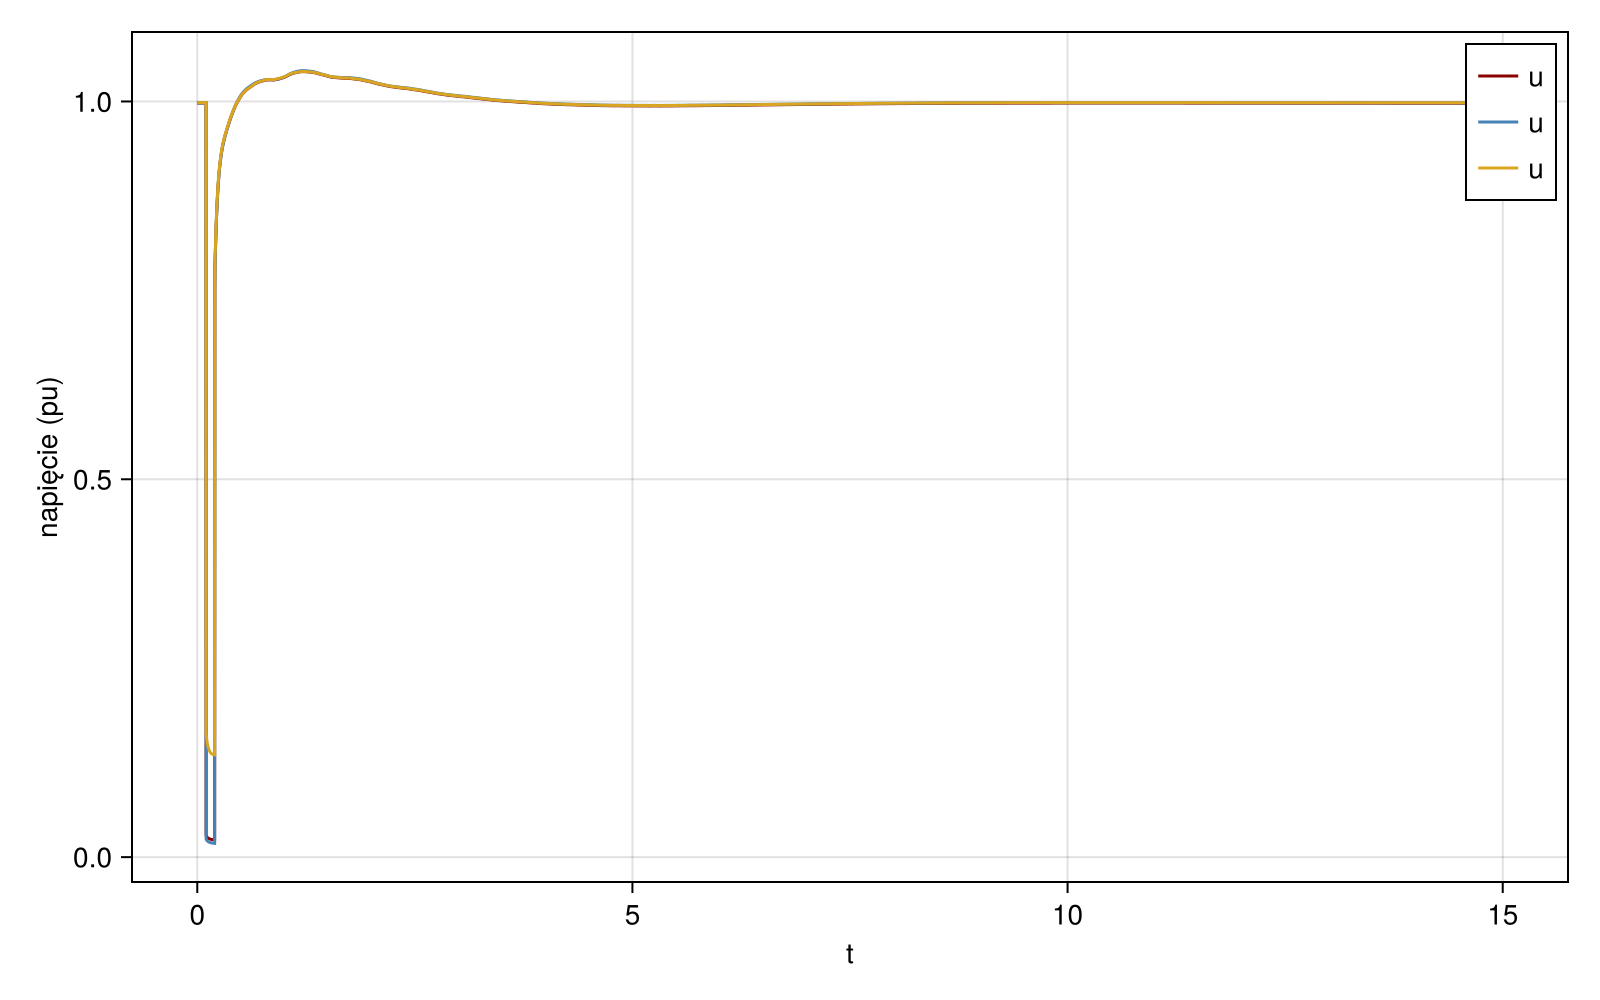

In [43]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="napięcie (pu)")
    
    # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊ω ), color=:darkred, label="ω")
     lines!(ax, sol5, idxs=VIndex(Symbol("87772593"), :busbar₊u_mag ), color=:darkred, label="u")
     lines!(ax, sol5, idxs=VIndex(Symbol("87772589_junction_start"), :busbar₊u_mag ), color=:steelblue, label="u")
     lines!(ax, sol5, idxs=VIndex(Symbol("770526753"), :busbar₊u_mag ), color=:goldenrod, label="u")

    # CairoMakie.xlims!(ax, 1.0, 10.0)
    # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
        
    axislegend(ax, position=:rt)
    fig
end

In [76]:
sol5.t[end]

34.96280619068584

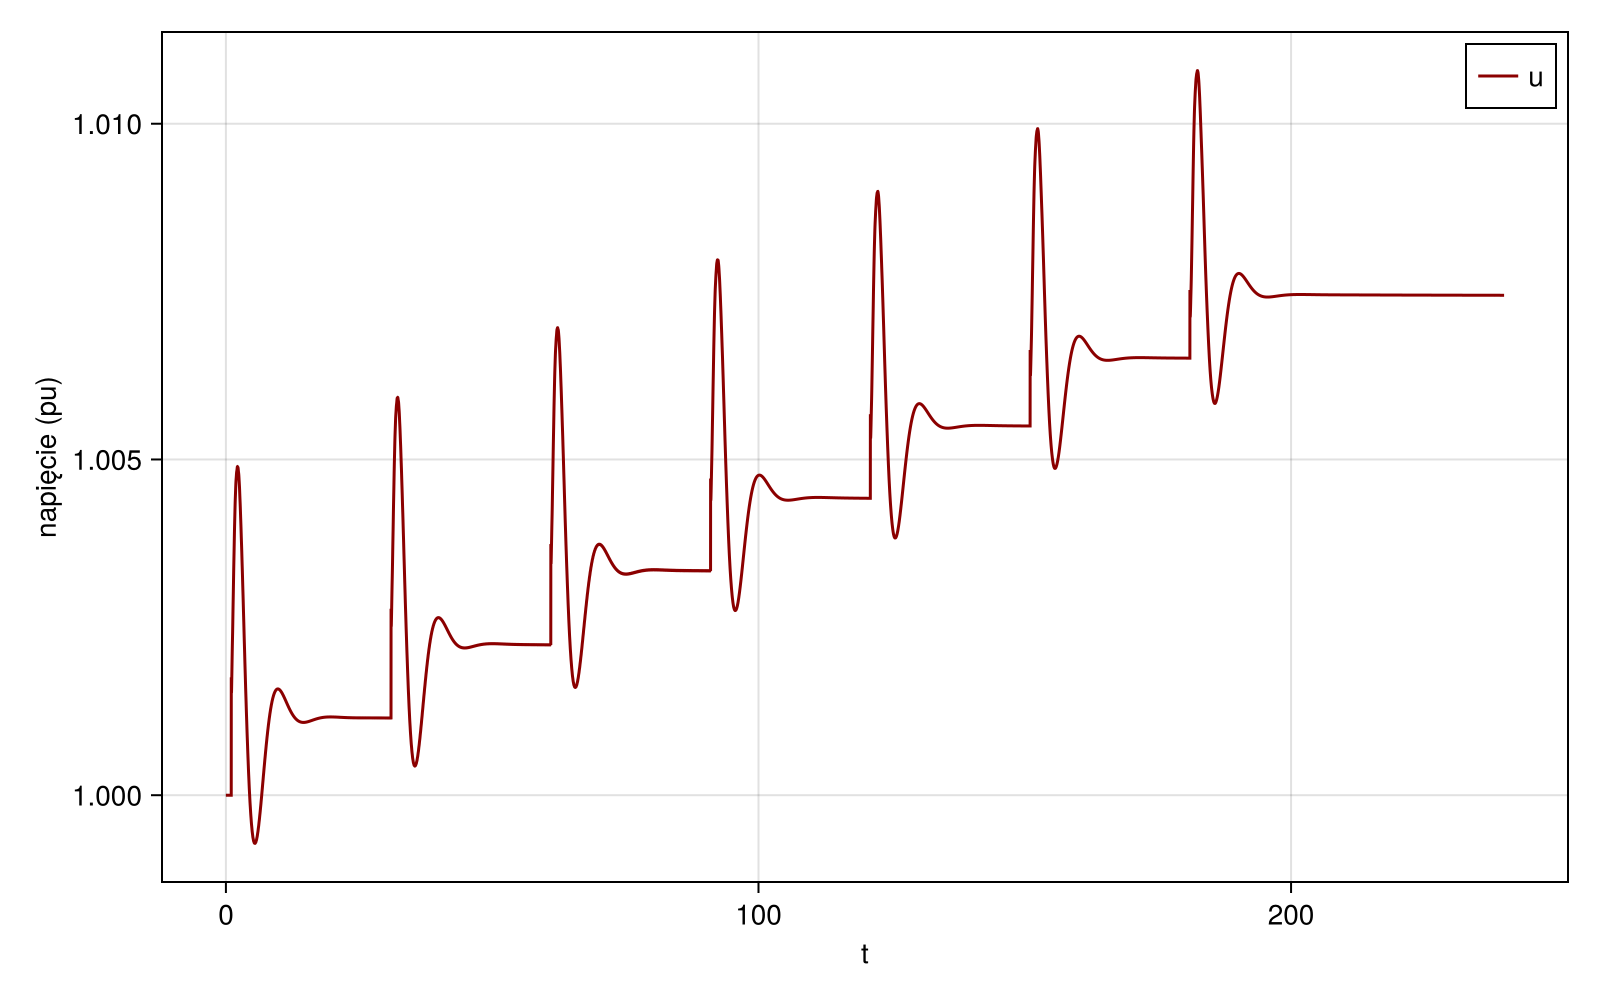

In [32]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="napięcie (pu)")
    
    # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊ω ), color=:darkred, label="ω")
     lines!(ax, sol5, idxs=VIndex(1, :busbar₊u_mag ), color=:darkred, label="u")


    # CairoMakie.xlims!(ax, 1.0, 10.0)
    # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
        
    axislegend(ax, position=:rt)
    fig
end

In [17]:
data = JSON3.read(read("names.json", String))
sol6 = deserialize("sim/aashort.jld2")
println("finished")

finished


In [14]:
data = JSON3.read(read("names.json", String))
sol5 = deserialize("sim/cincreaseSlowFROM85.jld2")
println("finished")

finished


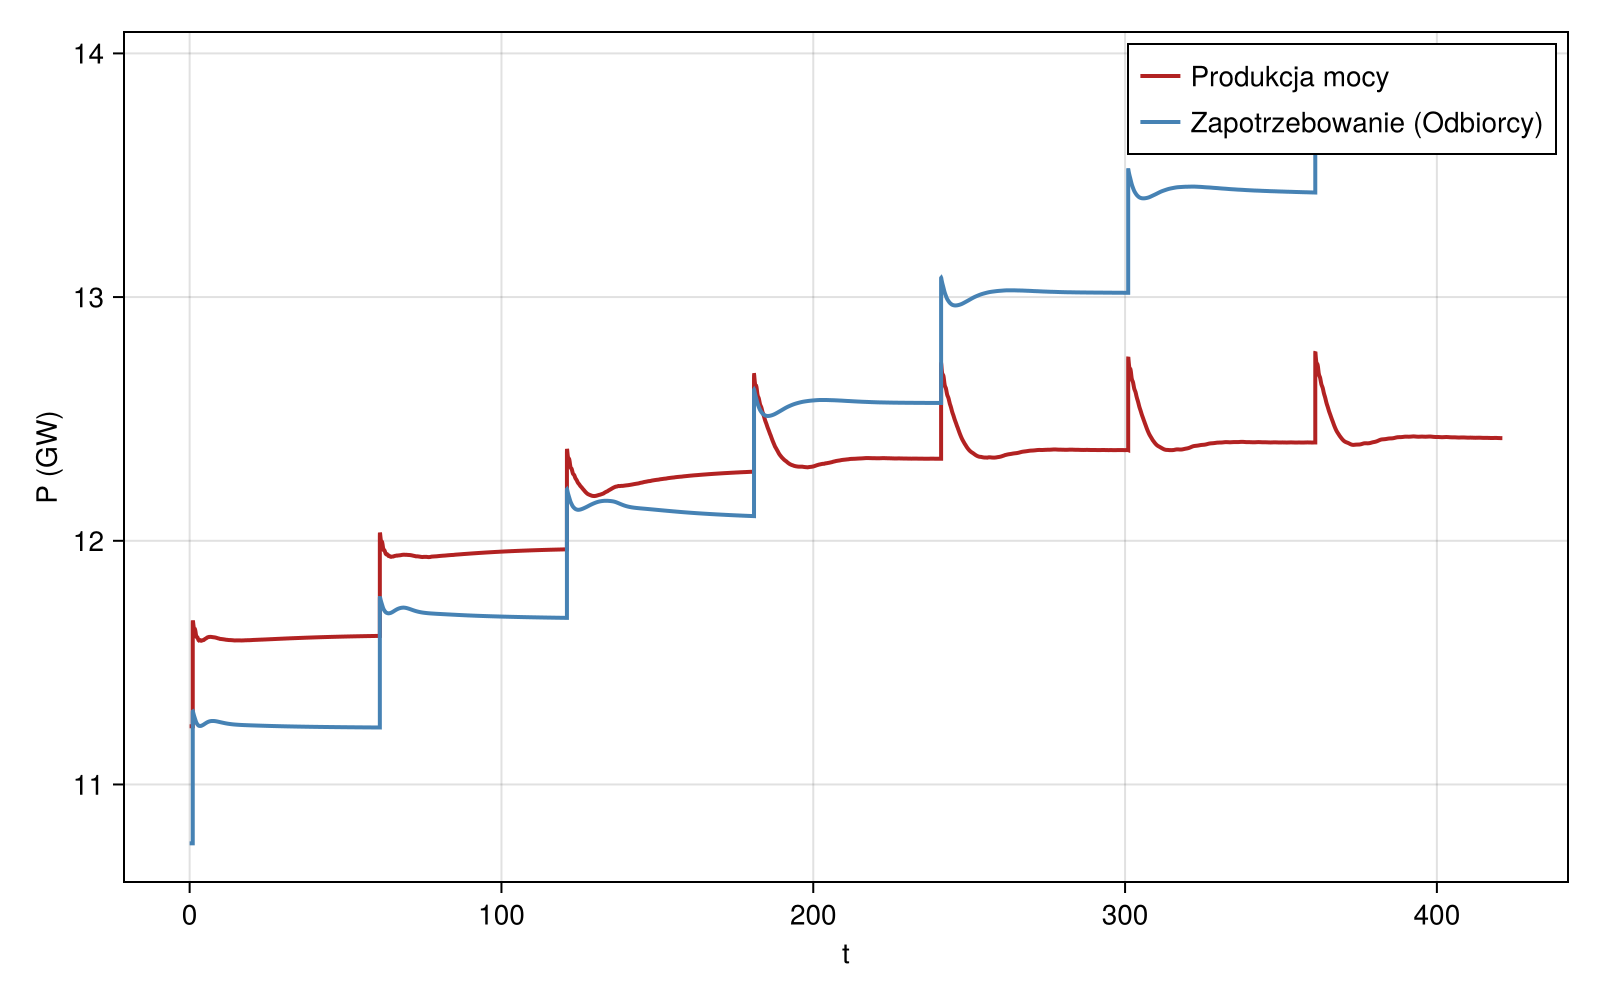

In [15]:
let
    fig = Figure(size = (800, 500))
    ax = Axis(fig[1, 1], title = "", xlabel = "t", ylabel = "P (GW)")

    total_power = zeros(length(sol5.t))
    total_load = zeros(length(sol5.t))
    
    for name in data.nodes     
        parts = split(string(name), "_")

        if length(parts) != 2
            continue
        end

        if parts[2] == "plant"
            total_power .+= sol5(sol5.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end

        if parts[2] == "load"
            total_load .-= sol5(sol5.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end
    end

    lines!(ax, sol5.t, total_power, color = :firebrick, linewidth = 2, label="Produkcja mocy")

    lines!(ax, sol5.t, total_load, color = :steelblue, linewidth = 2, label="Zapotrzebowanie (Odbiorcy)")

    # CairoMakie.xlims!(ax, 0.0, 23.0)
    axislegend(ax, position=:rt)

    fig
end

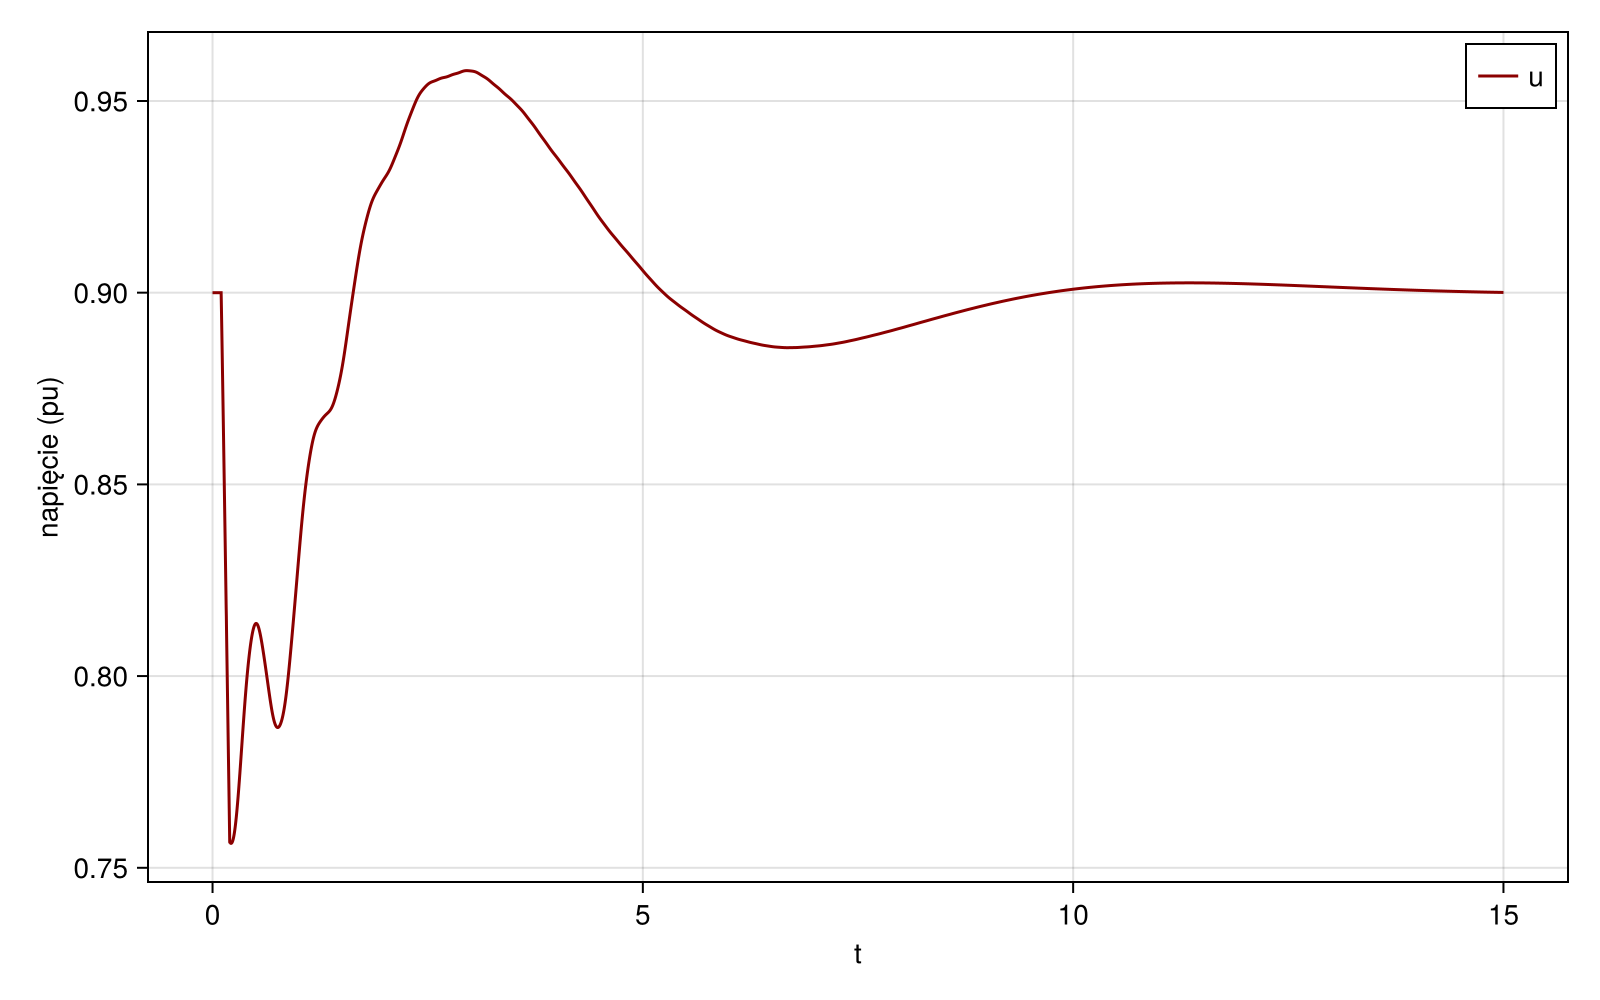

In [18]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="napięcie (pu)")
    
    # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊ω ), color=:darkred, label="ω")
     lines!(ax, sol6, idxs=VIndex(1, :ctrld_gen₊gov₊ref_sig ), color=:darkred, label="u")


    # CairoMakie.xlims!(ax, 0.0, 23.0)
    # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
        
    axislegend(ax, position=:rt)
    fig
end

In [17]:
data = JSON3.read(read("names.json", String))
sol6 = deserialize("sims/aashort11.jld2")
println("finished")

finished


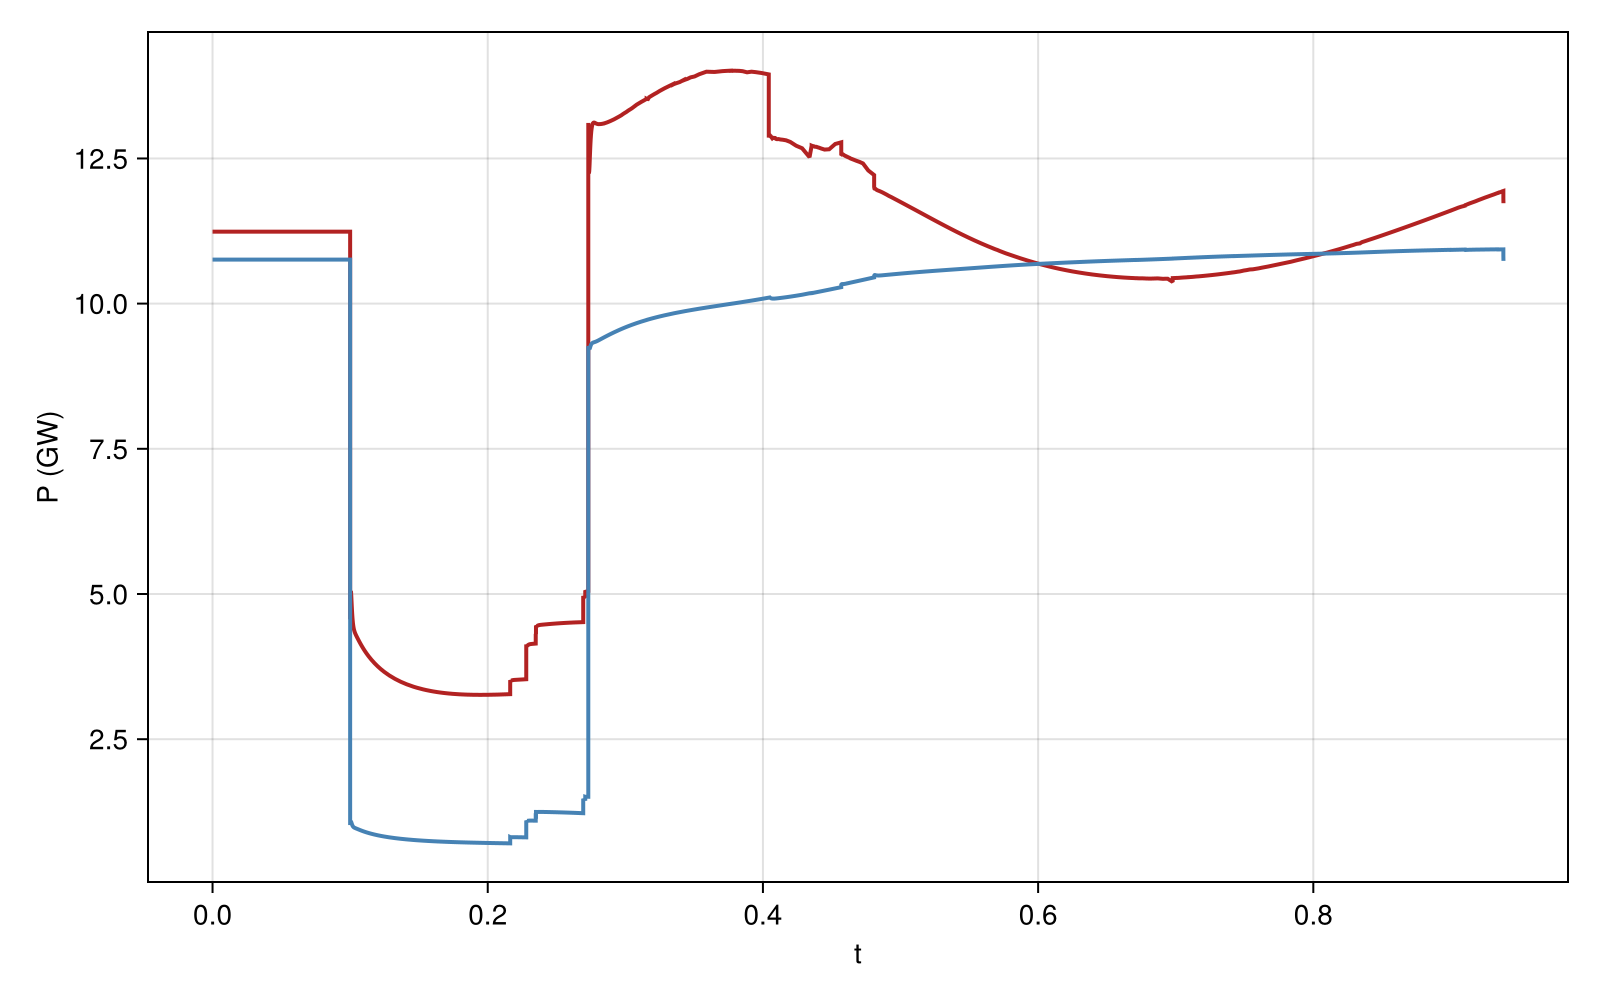

In [18]:
let
    fig = Figure(size = (800, 500))
    ax = Axis(fig[1, 1], title = "", xlabel = "t", ylabel = "P (GW)")

    total_power = zeros(length(sol6.t))
    total_load = zeros(length(sol6.t))
    
    for name in data.nodes     
        parts = split(string(name), "_")

        if length(parts) != 2
            continue
        end

        if parts[2] == "plant"
            total_power .+= sol6(sol6.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end

        if parts[2] == "load"
            total_load .-= sol6(sol6.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end
    end

    lines!(ax, sol6.t, total_power, color = :firebrick, linewidth = 2, label="Produkcja mocy")

    lines!(ax, sol6.t, total_load, color = :steelblue, linewidth = 2, label="Zapotrzebowanie (Odbiorcy)")

    # CairoMakie.xlims!(ax, 0.0, 23.0)
    # axislegend(ax, position=:rt)

    fig
end

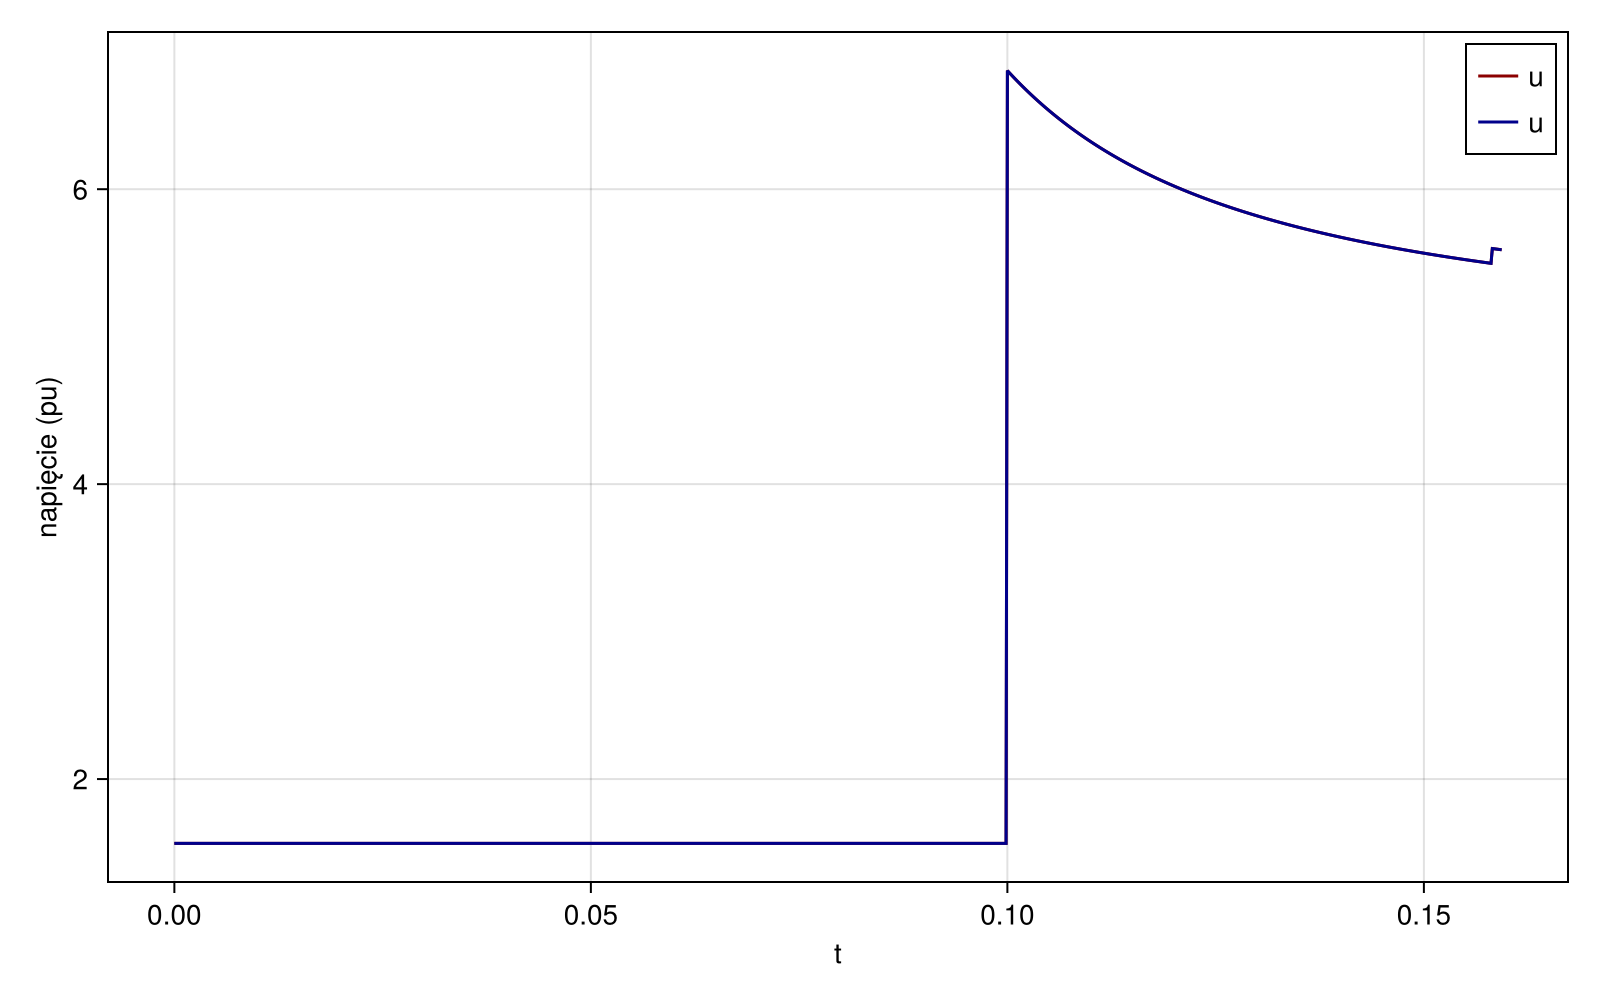

In [9]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="napięcie (pu)")
    
    # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊ω ), color=:darkred, label="ω")
     lines!(ax, sol6, idxs=EIndex(1, :dst₊i_mag ), color=:darkred, label="u")
     lines!(ax, sol6, idxs=EIndex(1, :src₊i_mag ), color=:darkblue, label="u")


    # CairoMakie.xlims!(ax, 0.0, 0.1)
    # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
        
    axislegend(ax, position=:rt)
    fig
end

In [34]:
inverter_model = Library.IdealDroopInverter(; name=:droop, Vset=1)
bus_model = MTKBus(inverter_model; name=:invbus)
bus1 = compile_bus(MTKBus(inverter_model); vidx=1)

load_model = Library.ConstantYLoad(; name=:load)
bus2 = compile_bus(MTKBus(; name=:loadbus), vidx=2)
bus3 = compile_bus(MTKBus(load_model); name=:loadbus, vidx=3)

l = MTKLine(Library.PiLine_fault(;R=0.001, X=0.02, G_src=0, B_src=0, G_dst=0, B_dst=0, name=:piline))
line12 = compile_line(l; src=1, dst=2, piline₊R=0.01)
line13 = compile_line(l; src=1, dst=3, piline₊R=0.01)
line23 = compile_line(l; src=2, dst=3, piline₊R=0.01)

set_pfmodel!(bus1, pfSlack(V=1))
set_pfmodel!(bus2, pfPQ(P=0, Q=0))
set_pfmodel!(bus3, pfPQ(P=-0.6, Q=-0.2))

nw = Network([bus1, bus2, bus3], [line12, line13, line23])
s0 = initialize_from_pf(nw; verbose=false, subverbose=false)


affect = ComponentAffect([], [:piline₊active]) do u, p, ctx
    @info "Line $(ctx.src)→$(ctx.dst) disconnected at t = $(ctx.t)s"
    p[:piline₊active] = 0
end

cb = PresetTimeComponentCallback(0.1, affect)
set_callback!(line13, cb)
set_callback!(line23, cb)

prob = ODEProblem(nw, s0, (0.0, 5.0))
sol = solve(prob, FBDF());

[ Info: Line 1→3 disconnected at t = 0.1s
[ Info: Line 2→3 disconnected at t = 0.1s


In [35]:
sol.t

40-element Vector{Float64}:
 0.0
 1.0e-6
 0.1
 0.1
 0.1
 0.1
 0.100001
 0.10002601153199019
 0.100337694499533
 0.10135543912965919
 0.10264935705529503
 0.10410379440571221
 0.1055582317561294
 ⋮
 1.7302658861962386
 2.04331215890866
 2.3563584316210813
 2.6694047043335027
 2.982450977045924
 3.2954972497583457
 3.608543522470767
 3.9215897951831886
 4.23463606789561
 4.547682340608032
 4.860728613320453
 5.0

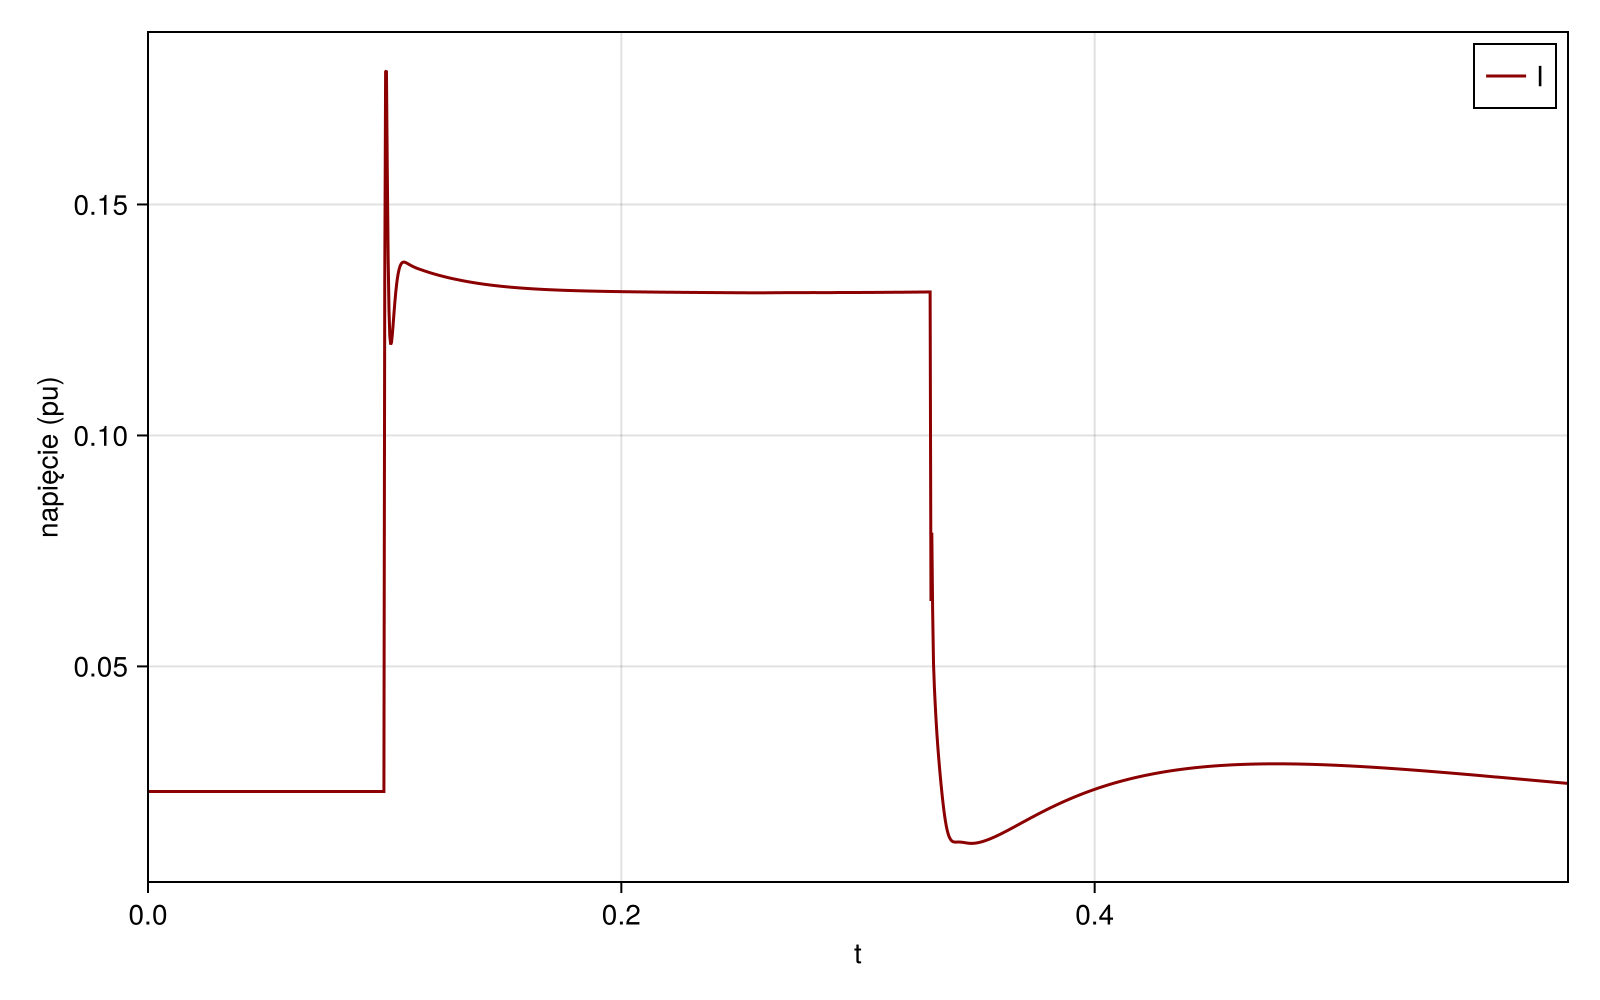

In [13]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="napięcie (pu)")
    
    # lines!(ax, sol6, idxs=VIndex(1, :busbar₊P ), color=:darkred, label="I")
    # lines!(ax, sol5, idxs=VIndex(423, :busbar₊i_mag ), color=:darkred, label="P")
     lines!(ax, sol6, idxs=EIndex(189, :src₊i_mag ), color=:darkred, label="I")


    CairoMakie.xlims!(ax, 0.0, 0.6)
    # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
        
    axislegend(ax, position=:rt)
    fig
end

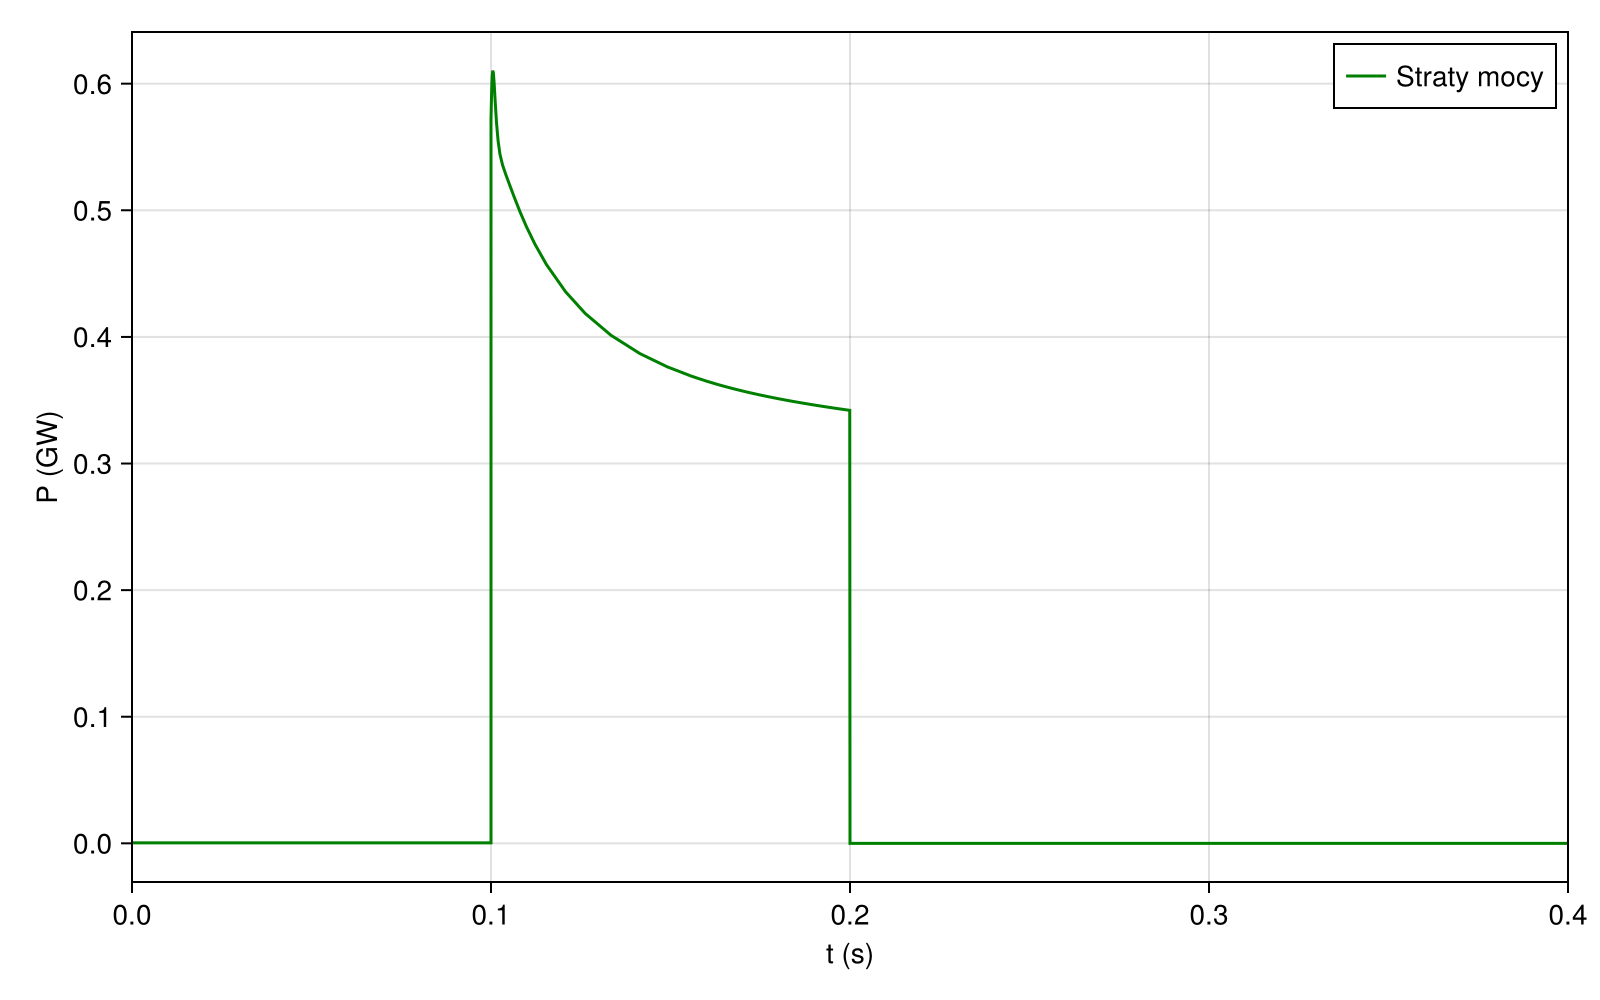

In [10]:
# let
#     fig = Figure()
#     fig = Figure(size = (800, 500))
#     cols = 1
    
#     ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="P (GW)")
#     # total = zeros(length(sol5.t)) 
#     # total .+= 
#     # total .+= 
    
#     lines!(ax, sol5.t, sol5(sol5.t, idxs=EIndex(187, :src₊P )).u .+ sol5(sol5.t, idxs=EIndex(187, :dst₊P )).u, color=:darkred, label="Moc Stracona")
    
#     # # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊ω ), color=:darkred, label="ω")

#      # lines!(ax, sol5, idxs=EIndex(187, :src₊P ), color=:darkred, label="src")
#      # lines!(ax, sol5, idxs=EIndex(187, :dst₊P ), color=:darkblue, label="dst")

#     CairoMakie.xlims!(ax, 0.0, 0.4)
#     # CairoMakie.xlims!(ax, 1.0, 10.0)
#     # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
    
#     axislegend(ax, position=:rt)
#     fig
# end

let
    fig = Figure(size = (800, 500))
    cols = 2

    total_power = zeros(length(sol5.t))
    
    ax = Axis(fig[1, 1], title="", xlabel="t (s)", ylabel="P (GW)")

    total_power .-= sol5(sol5.t, idxs=EIndex(187, :src₊P)).u
    total_power .-= sol5(sol5.t, idxs=EIndex(187, :dst₊P)).u

    total_power[9] = 0.0004187974526566052
    total_power[10] = 0.0004187974526566052
    
    # Zmiana tutaj: używamy sol5.t (czasy) zamiast całego obiektu sol5
    lines!(ax, sol5.t, total_power, color=:green, label="Straty mocy")
    CairoMakie.xlims!(ax, 0.0, 0.4)
    axislegend(ax, position=:rt)
    fig
end

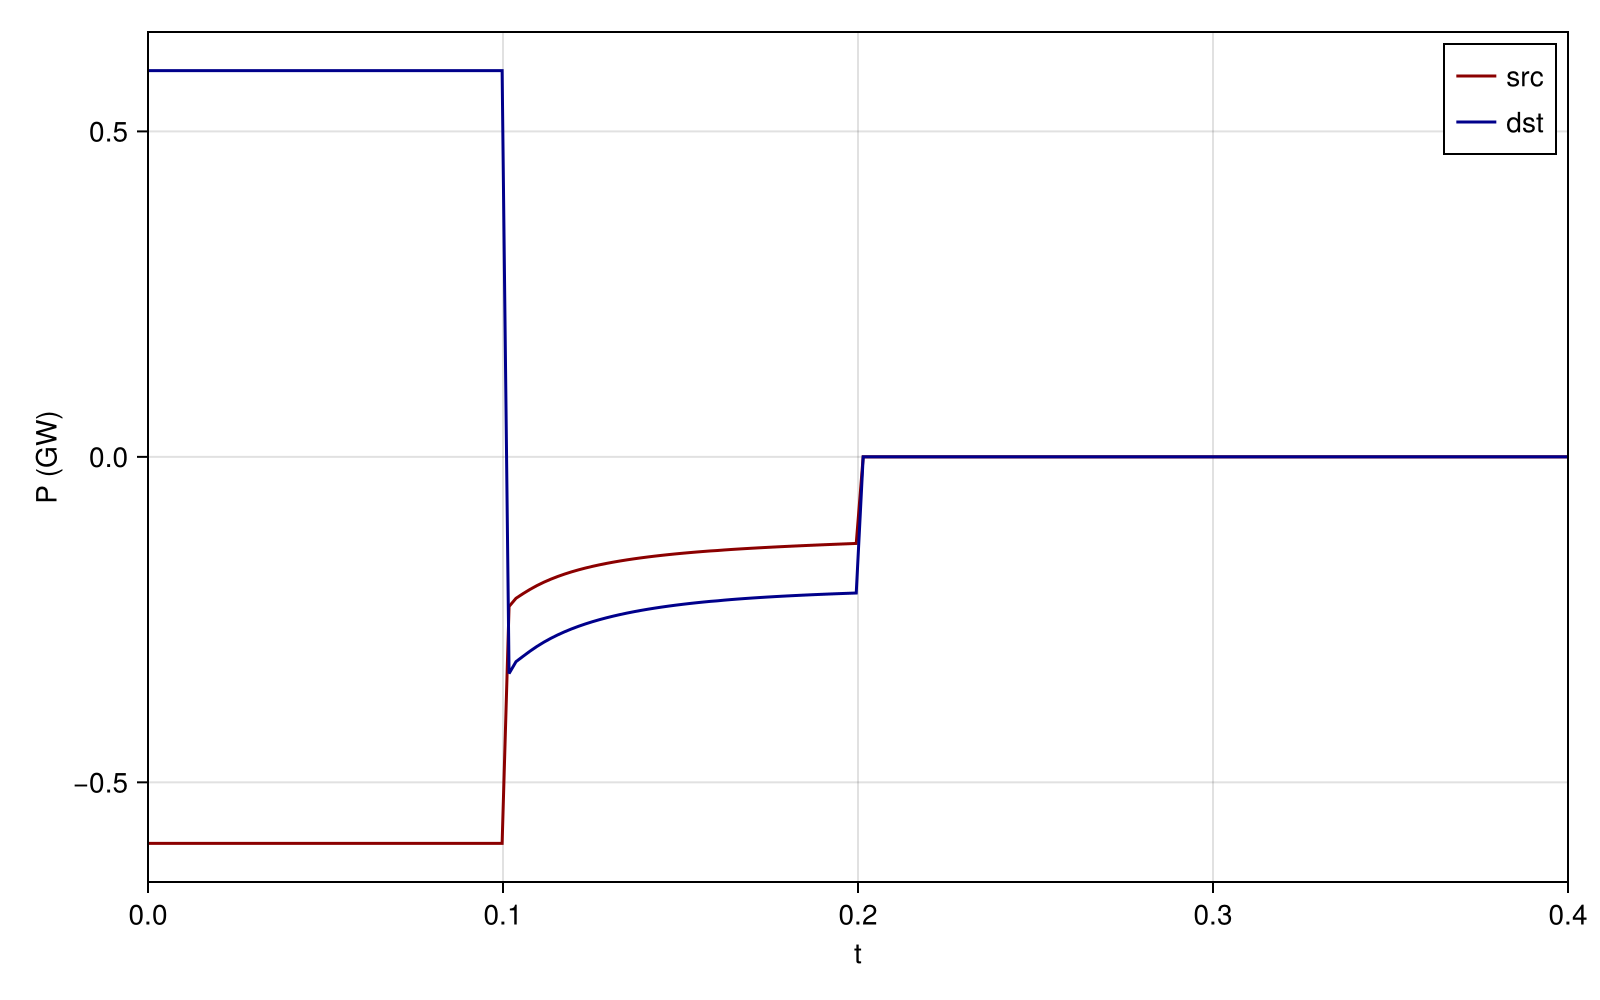

In [3]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="P (GW)")
#     # total = zeros(length(sol5.t)) 
#     # total .+= 
#     # total .+= 
    
#     lines!(ax, sol5.t, sol5(sol5.t, idxs=EIndex(187, :src₊P )).u .+ sol5(sol5.t, idxs=EIndex(187, :dst₊P )).u, color=:darkred, label="Moc Stracona")
    
#     # # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊ω ), color=:darkred, label="ω")

     lines!(ax, sol5, idxs=EIndex(187, :src₊P ), color=:darkred, label="src")
     lines!(ax, sol5, idxs=EIndex(187, :dst₊P ), color=:darkblue, label="dst")

    CairoMakie.xlims!(ax, 0.0, 0.4)
#     # CairoMakie.xlims!(ax, 1.0, 10.0)
#     # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
    
    axislegend(ax, position=:rt)
    fig
end

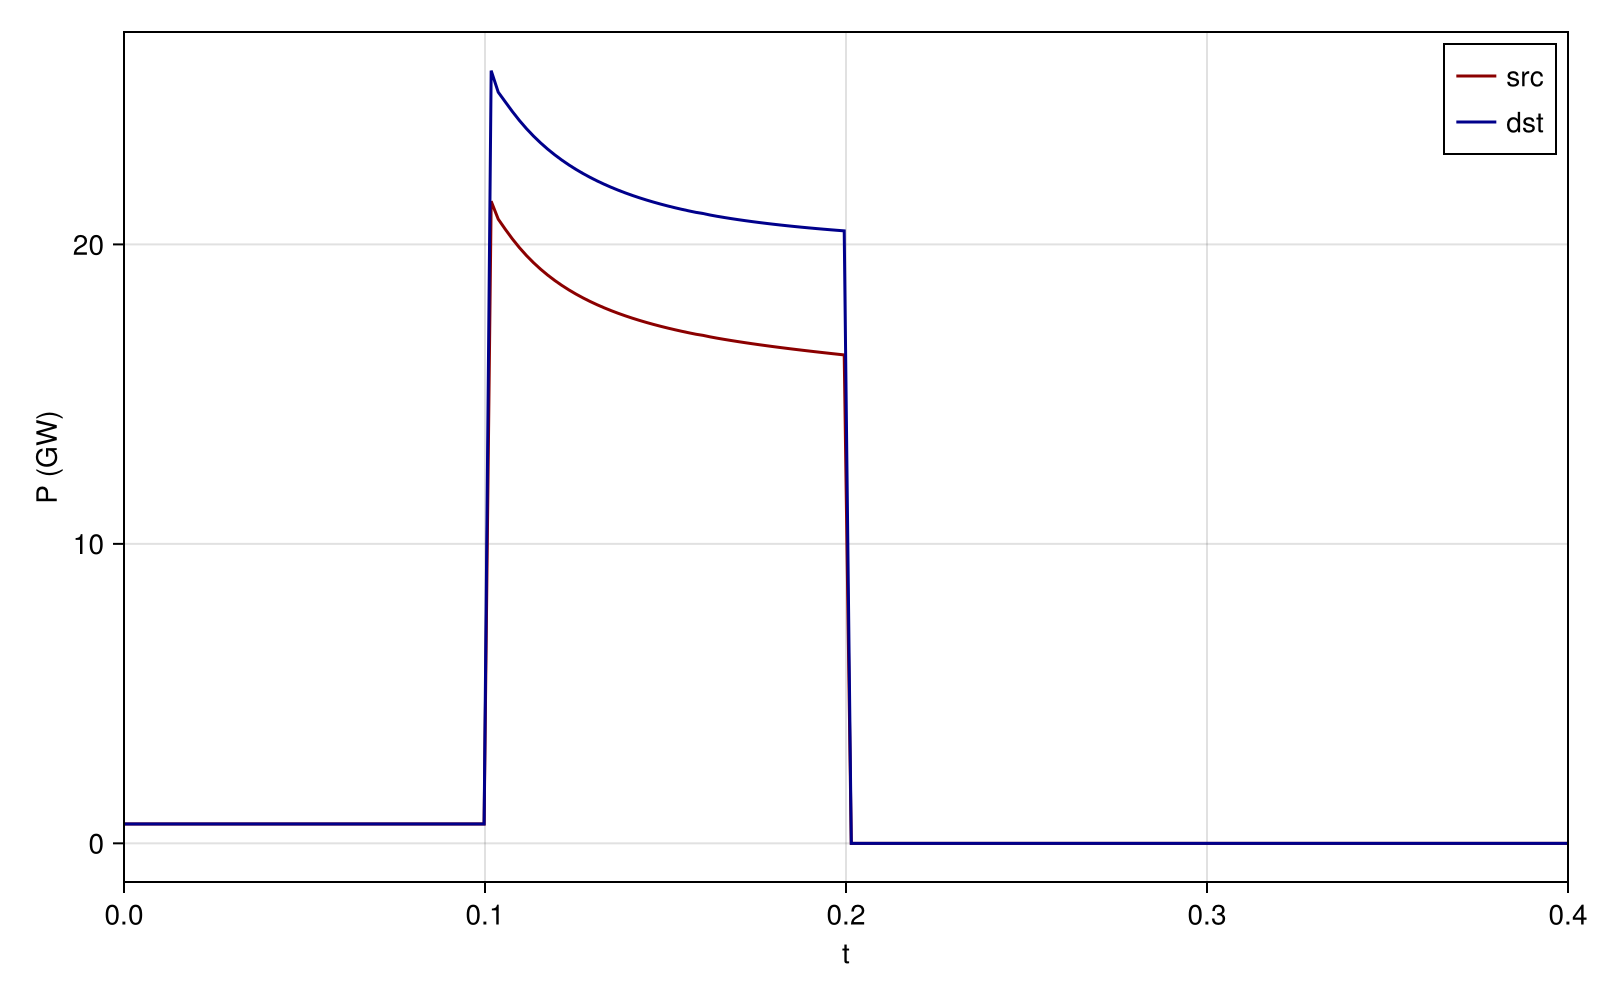

In [12]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="P (GW)")
#     # total = zeros(length(sol5.t)) 
#     # total .+= 
#     # total .+= 
    
#     lines!(ax, sol5.t, sol5(sol5.t, idxs=EIndex(187, :src₊P )).u .+ sol5(sol5.t, idxs=EIndex(187, :dst₊P )).u, color=:darkred, label="Moc Stracona")
    
#     # # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊ω ), color=:darkred, label="ω")

     lines!(ax, sol5, idxs=EIndex(187, :src₊i_mag ), color=:darkred, label="src")
     lines!(ax, sol5, idxs=EIndex(187, :dst₊i_mag ), color=:darkblue, label="dst")

    CairoMakie.xlims!(ax, 0.0, 0.4)
#     # CairoMakie.xlims!(ax, 1.0, 10.0)
#     # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
    
    axislegend(ax, position=:rt)
    fig
end

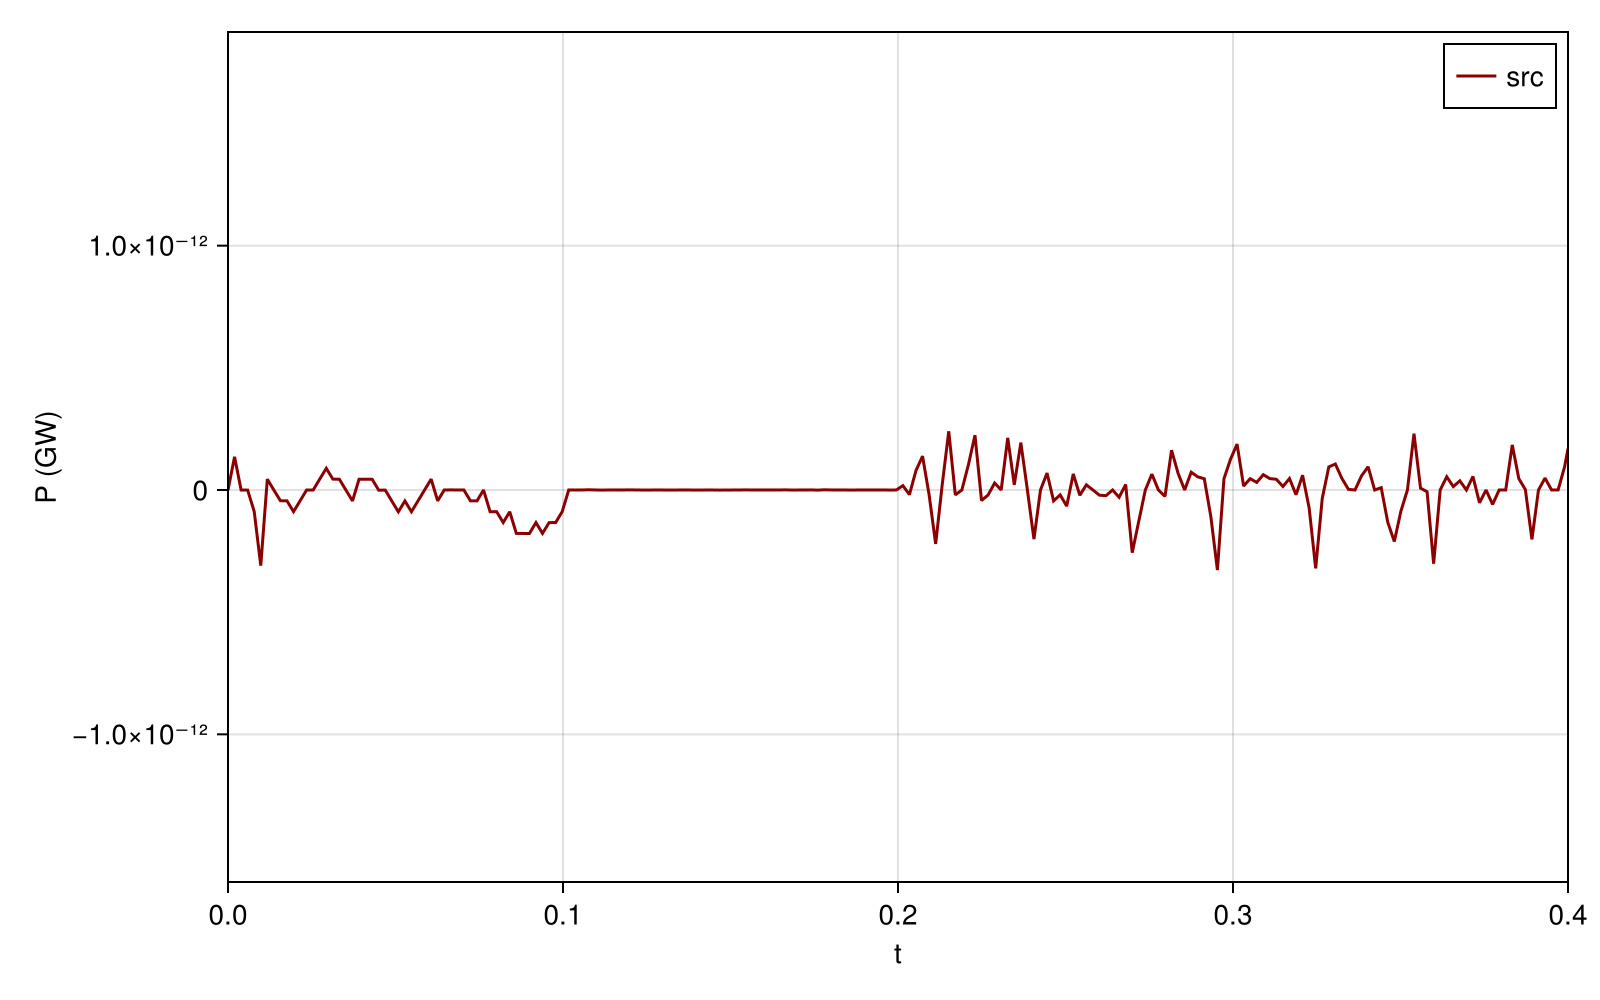

In [4]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="P (GW)")
#     # total = zeros(length(sol5.t)) 
#     # total .+= 
#     # total .+= 
    
#     lines!(ax, sol5.t, sol5(sol5.t, idxs=EIndex(187, :src₊P )).u .+ sol5(sol5.t, idxs=EIndex(187, :dst₊P )).u, color=:darkred, label="Moc Stracona")
    
#     # # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊ω ), color=:darkred, label="ω")

     lines!(ax, sol5, idxs=VIndex(Symbol("87772593"), :busbar₊P ), color=:darkred, label="src")
     # lines!(ax, sol5, idxs=EIndex(187, :dst₊P ), color=:darkblue, label="dst")

    CairoMakie.xlims!(ax, 0.0, 0.4)
#     # CairoMakie.xlims!(ax, 1.0, 10.0)
#     # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
    
    axislegend(ax, position=:rt)
    fig
end

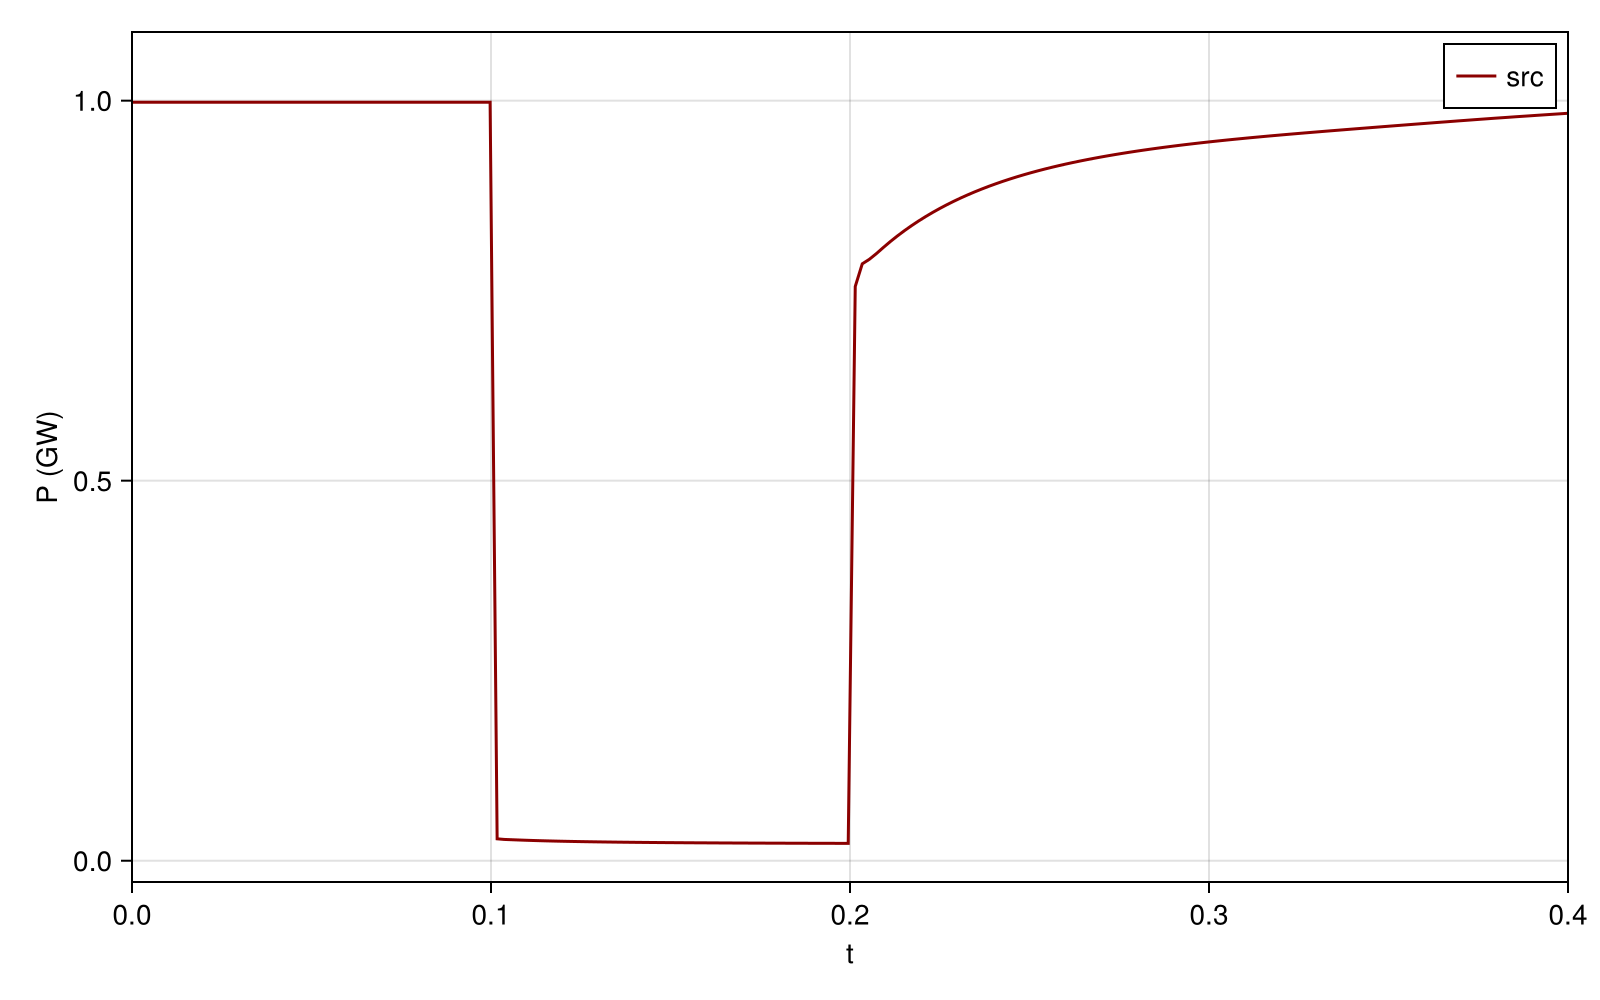

In [6]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="P (GW)")
#     # total = zeros(length(sol5.t)) 
#     # total .+= 
#     # total .+= 
    
#     lines!(ax, sol5.t, sol5(sol5.t, idxs=EIndex(187, :src₊P )).u .+ sol5(sol5.t, idxs=EIndex(187, :dst₊P )).u, color=:darkred, label="Moc Stracona")
    
#     # # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊ω ), color=:darkred, label="ω")

     lines!(ax, sol5, idxs=VIndex(Symbol("87772593"), :busbar₊u_mag ), color=:darkred, label="src")
     # lines!(ax, sol5, idxs=EIndex(187, :dst₊P ), color=:darkblue, label="dst")

    CairoMakie.xlims!(ax, 0.0, 0.4)
#     # CairoMakie.xlims!(ax, 1.0, 10.0)
#     # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
    
    axislegend(ax, position=:rt)
    fig
end

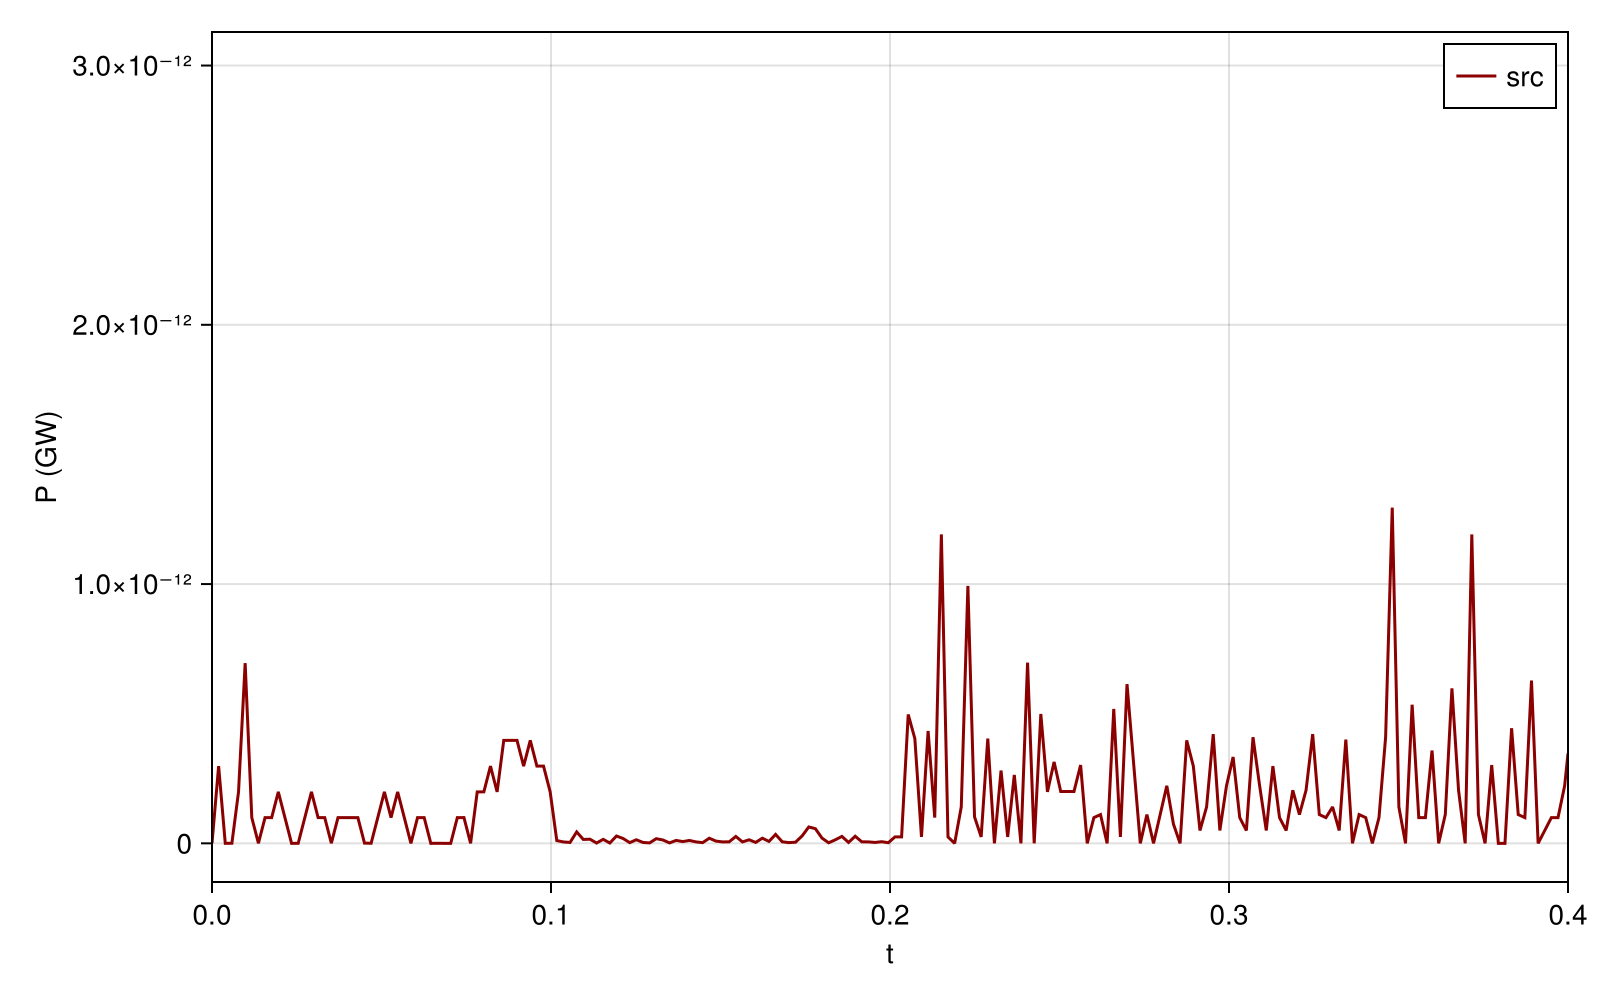

In [7]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="P (GW)")
#     # total = zeros(length(sol5.t)) 
#     # total .+= 
#     # total .+= 
    
#     lines!(ax, sol5.t, sol5(sol5.t, idxs=EIndex(187, :src₊P )).u .+ sol5(sol5.t, idxs=EIndex(187, :dst₊P )).u, color=:darkred, label="Moc Stracona")
    
#     # # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊ω ), color=:darkred, label="ω")

     lines!(ax, sol5, idxs=VIndex(Symbol("87772593"), :busbar₊i_mag ), color=:darkred, label="src")
     # lines!(ax, sol5, idxs=EIndex(187, :dst₊P ), color=:darkblue, label="dst")

    CairoMakie.xlims!(ax, 0.0, 0.4)
#     # CairoMakie.xlims!(ax, 1.0, 10.0)
#     # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
    
    axislegend(ax, position=:rt)
    fig
end

In [62]:
sol5(sol5.t, idxs=EIndex(Symbol("8591150_temp8591150_plant"), :src₊P))

t: 4036-element Vector{Float64}:
  0.0
  1.0e-6
  5.278788780039721e-5
  0.00637335479421733
  0.1
  0.1
  0.100001
  0.10000119155968498
  0.10000154729925616
  0.10000190303882733
  0.10000225877839851
  0.10000261451796968
  0.10000357745862876
  ⋮
 14.953528419645938
 14.956919325853967
 14.960310232061996
 14.963701138270025
 14.967092044478054
 14.971966834539852
 14.977397497474179
 14.982828160408506
 14.988258823342832
 14.993689486277159
 14.999120149211485
 15.0
u: 4036-element Vector{Float64}:
 2.9975392780669647
 2.9975392778331527
 2.9975392778356174
 2.997539277884672
 2.9975392780164065
 2.9975392780164065
 1.1361310511064613
 1.1360018825150366
 1.1357622908223552
 1.1355230441699975
 1.1352841568317016
 1.1350456332687027
 1.134401802676418
 ⋮
 2.9978559169307566
 2.99785764792311
 2.997859547425387
 2.99786156069347
 2.9978636462841357
 2.997866665383251
 2.997869891398797
 2.997872755827509
 2.997875087326282
 2.9978767104418194
 2.997877541173282
 2.997877592966322

In [60]:
    total_power = zeros(length(sol5.t))


    total_power .+= sol5(sol5.t, idxs=EIndex(187, :src₊P)).u

total_power

4036-element Vector{Float64}:
   -0.5937896554562906
   -0.5937896556193468
   -0.5937896556192778
   -0.5937896555924052
 -398.37923424373383
 -398.37923424373383
   -0.2355289308928611
   -0.2355359674649934
   -0.2355490441376792
   -0.23556213308371293
   -0.23557523404211256
   -0.23558834686227215
   -0.2356239003469699
    ⋮
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0

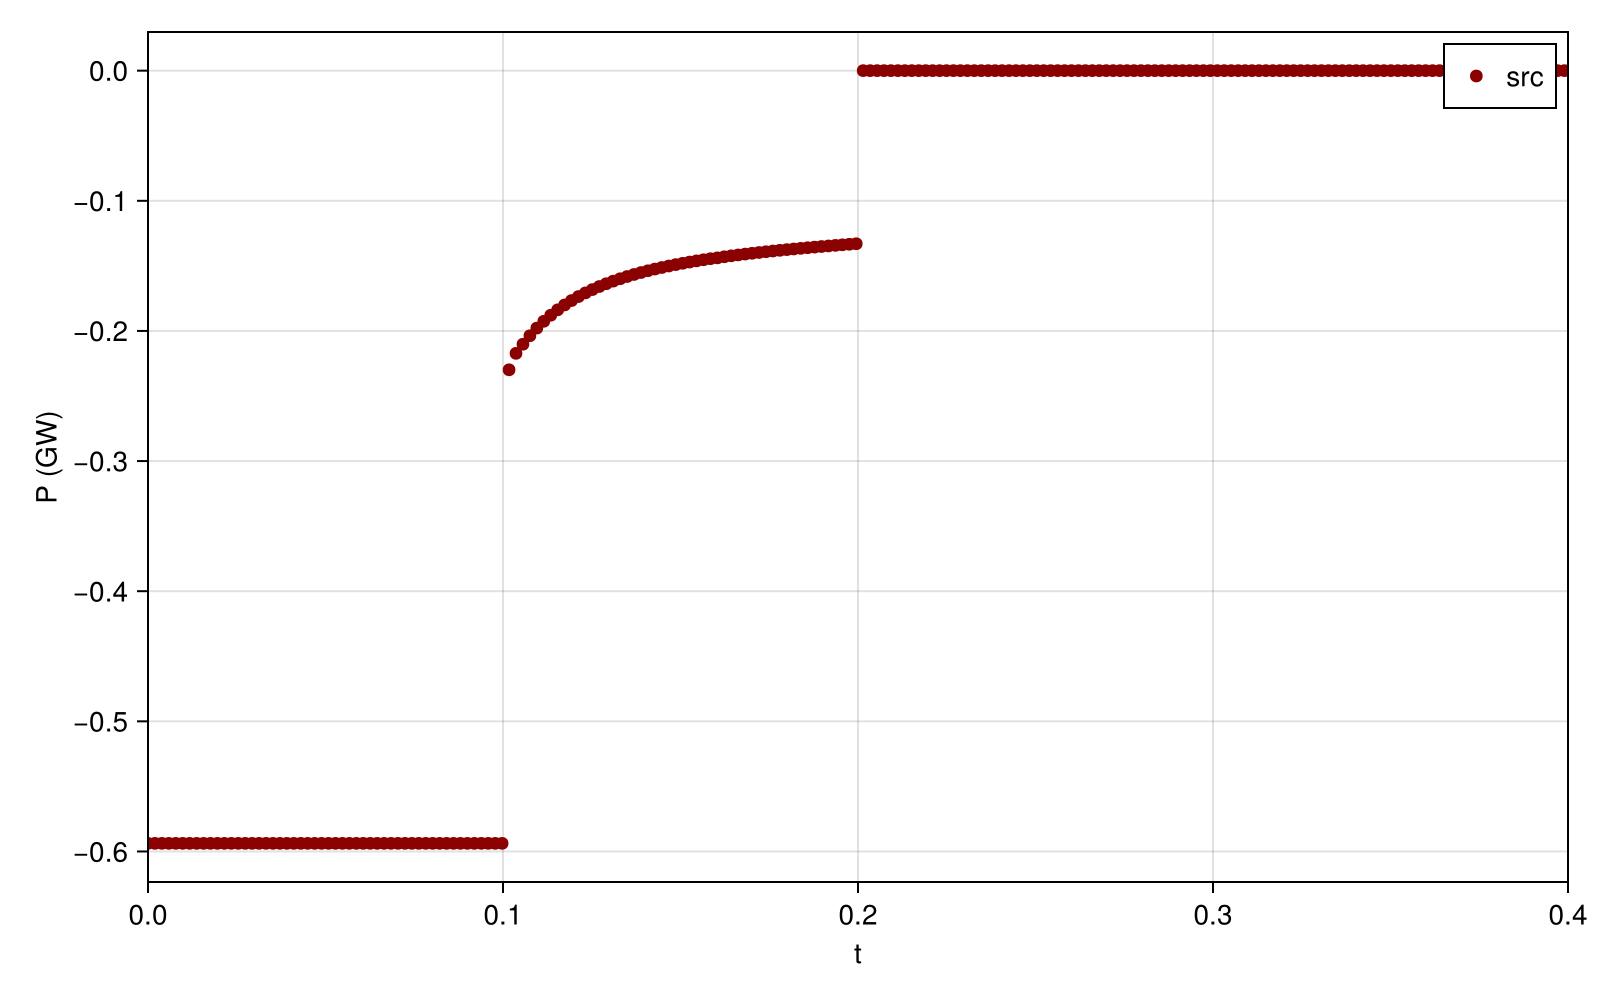

In [50]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="P (GW)")

     CairoMakie.scatter!(ax, sol5, idxs=EIndex(187, :src₊P), color=:darkred, label="src")
     # lines!(ax, sol5, idxs=EIndex(187, :dst₊P), color=:darkblue, label="dst")

    CairoMakie.xlims!(ax, 0.0, 0.4)
    
    axislegend(ax, position=:rt)
    fig
end

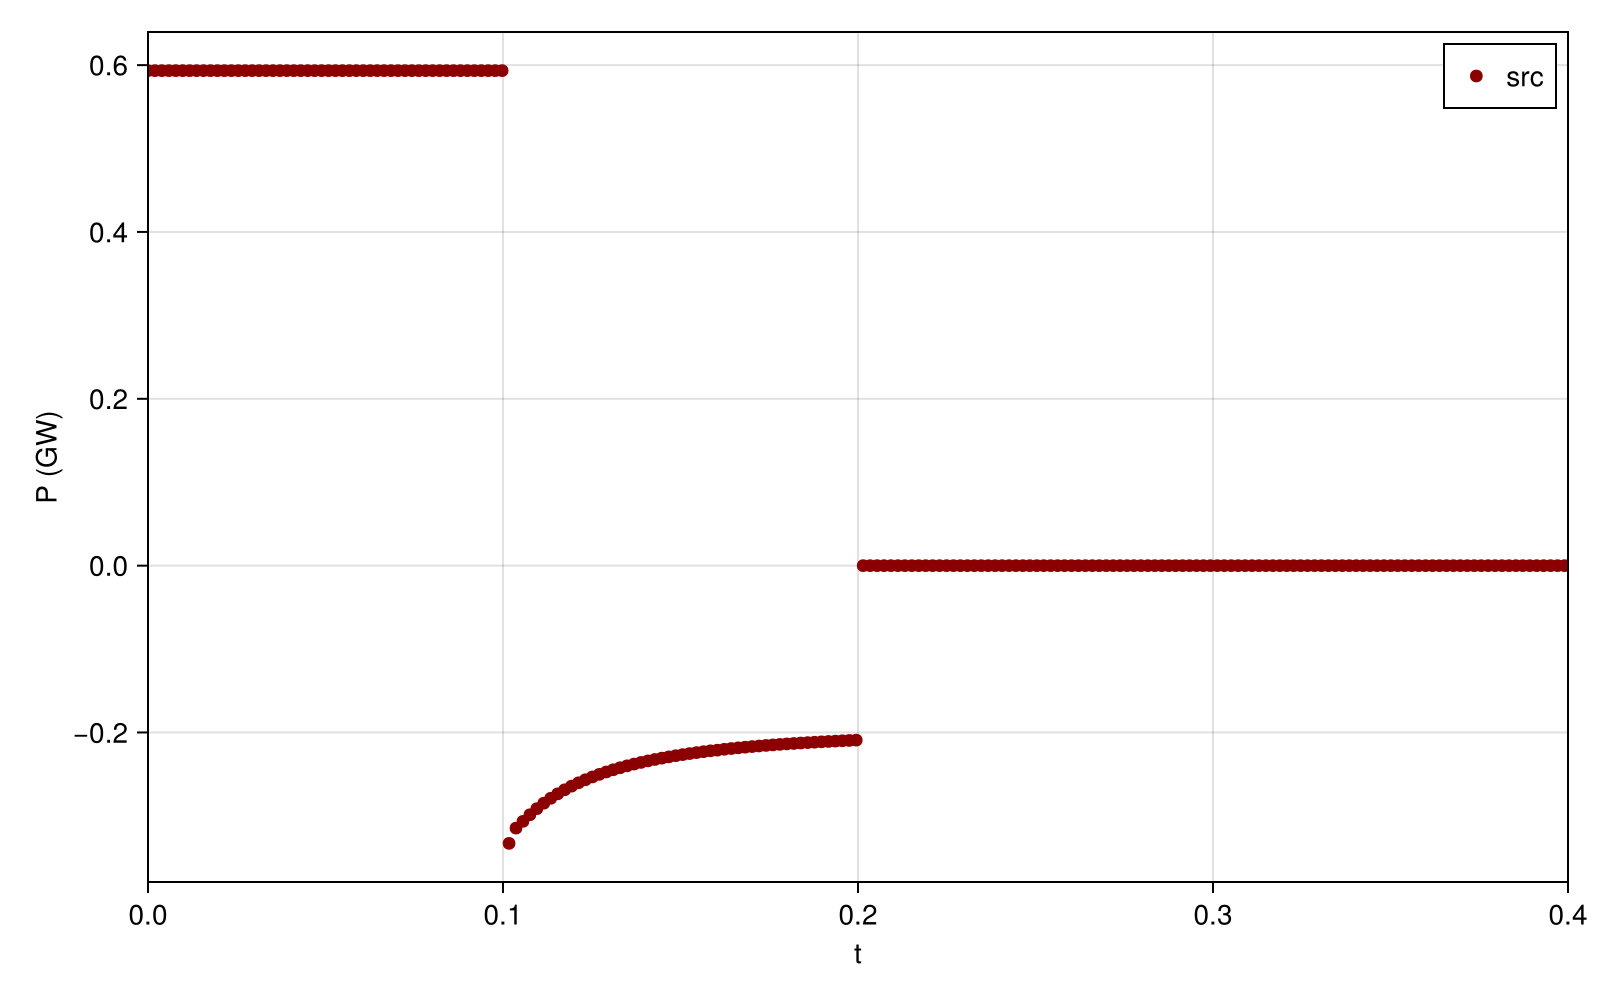

In [28]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="P (GW)")

     CairoMakie.scatter!(ax, sol5, idxs=EIndex(187, :dst₊P), color=:darkred, label="src")
     # lines!(ax, sol5, idxs=EIndex(187, :dst₊P), color=:darkblue, label="dst")

    CairoMakie.xlims!(ax, 0.0, 0.4)
    
    axislegend(ax, position=:rt)
    fig
end

In [35]:
sol5(sol5.t, idxs=EIndex(187, :src₊P))

t: 767-element Vector{Float64}:
  0.0
  1.0e-6
  9.634944348071542e-6
  6.816575426027355e-5
  0.0004281036808467
  0.0028923951623221937
  0.011694219629154672
  0.05859468019611698
  0.1
  0.1
  0.100001
  0.10001039912611351
  0.10004860845800687
  ⋮
 12.537985587547494
 12.711500913568425
 12.886973463311936
 13.064935723835958
 13.247501192703622
 13.439394988817313
 13.652109348694662
 13.878015139041189
 14.110835186113267
 14.3977079135537
 14.699620008689575
 15.0
u: 767-element Vector{Float64}:
   -0.5937896554562907
   -0.5937896556193303
   -0.5937896556192167
   -0.593789655619339
   -0.593789655619062
   -0.5937896556020812
   -0.5937896555708554
   -0.5937896555282242
 -398.37923424418847
 -398.37923424418847
   -0.23552894817479314
   -0.2358780945824044
   -0.23735165213611115
    ⋮
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0

In [34]:
sol5(sol5.t, idxs=EIndex(187, :dst₊P))

t: 767-element Vector{Float64}:
  0.0
  1.0e-6
  9.634944348071542e-6
  6.816575426027355e-5
  0.0004281036808467
  0.0028923951623221937
  0.011694219629154672
  0.05859468019611698
  0.1
  0.1
  0.100001
  0.10001039912611351
  0.10004860845800687
  ⋮
 12.537985587547494
 12.711500913568425
 12.886973463311936
 13.064935723835958
 13.247501192703622
 13.439394988817313
 13.652109348694662
 13.878015139041189
 14.110835186113267
 14.3977079135537
 14.699620008689575
 15.0
u: 767-element Vector{Float64}:
    0.5933708580037111
    0.5933708581665315
    0.5933708581664622
    0.5933708581665398
    0.593370858166263
    0.5933708581493559
    0.5933708581180939
    0.5933708580755676
 -398.31143496889484
 -398.31143496889484
   -0.336861049636044
   -0.3376071911451758
   -0.34079028311011383
    ⋮
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0

In [92]:
sol5.e[EIndex(187)]

LoadError: FieldError: type ODESolution has no field `e`, available fields: `u`, `u_analytic`, `errors`, `t`, `k`, `discretes`, `prob`, `alg`, `interp`, `dense`, `tslocation`, `stats`, `alg_choice`, `retcode`, `resid`, `original`, `saved_subsystem`

In [57]:
using Statistics

println(mean(diff(sol5.t)))

0.007288629737609329


┌ Warning: Using a `Vector{<:Real}` as a linestyle attribute is deprecated. Wrap it in a `Linestyle`.
└ @ Makie ~/.julia/packages/Makie/p9K7f/src/conversions.jl:1165


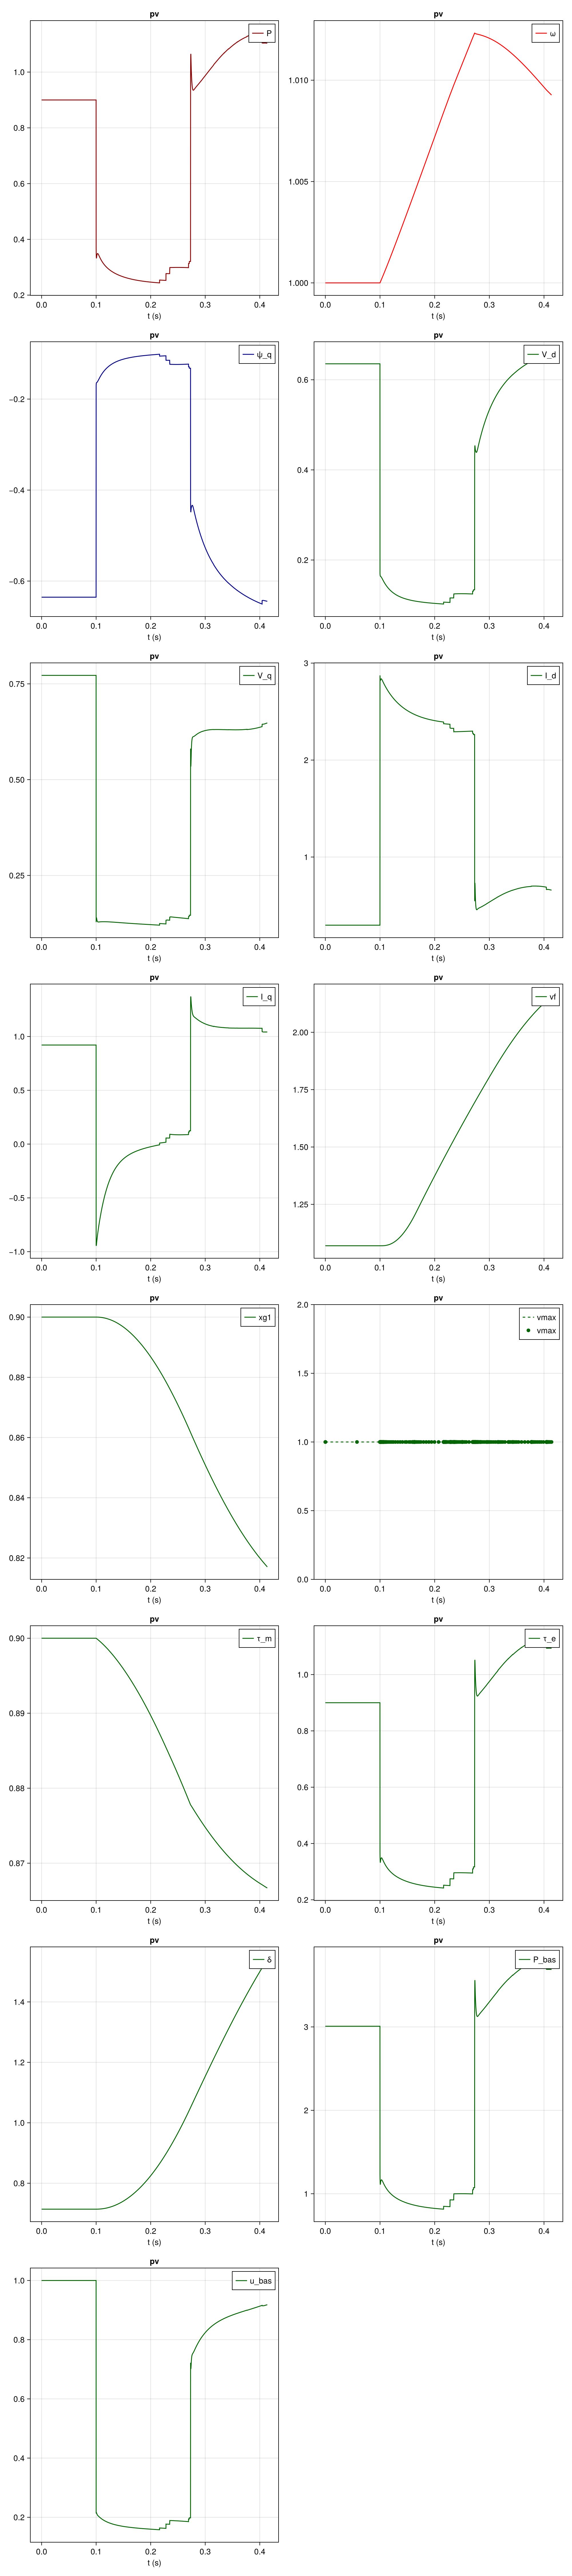

In [12]:
let
    cols = 2
    # Define the variables, their labels, and colors
    vars = [
        (:ctrld_gen₊other₊P, "P", :darkred),
        (:ctrld_gen₊other₊ω, "ω", :red),
        (:ctrld_gen₊other₊ψ_q, "ψ_q", :darkblue),
        (:ctrld_gen₊other₊V_d, "V_d", :darkgreen),
        (:ctrld_gen₊other₊V_q, "V_q", :darkgreen),
        (:ctrld_gen₊other₊I_d, "I_d", :darkgreen),
        (:ctrld_gen₊other₊I_q, "I_q", :darkgreen),
        (:ctrld_gen₊other₊vf, "vf", :darkgreen),
        (:ctrld_gen₊gov₊xg1, "xg1", :darkgreen),
        (:ctrld_gen₊gov₊V_max, "vmax", :darkgreen),
        (:ctrld_gen₊other₊τ_m, "τ_m", :darkgreen),
        (:ctrld_gen₊other₊τ_e, "τ_e", :darkgreen),
        (:ctrld_gen₊other₊δ, "δ", :darkgreen),
        (:busbar₊P, "P_bas", :darkgreen),
        (:busbar₊u_mag, "u_bas", :darkgreen)
    ]
    
    # Calculate rows needed based on 2 columns
    rows = ceil(Int, length(vars))
    
    # Initialize figure with an appropriate size
    fig = Figure(size = (500 * cols, rows * 300))
    
    # Loop through and create a subplot for each variable
    for (i, (var_sym, label_str, col_color)) in enumerate(vars)
r = div(i - 1, cols) + 1
    c = mod(i - 1, cols) + 1
        
        # Create axis in the grid position (r, c)
        ax = Axis(fig[r, c], title="pv", xlabel="t (s)")
        # Plot the specific variable
        lines!(ax, sol6, idxs=VIndex(Symbol(data.nodes[1]), var_sym), color=col_color, label=label_str)

        axislegend(ax, position=:rt)
    end
    
    fig
end

In [ ]:
let
    fig = Figure(size = (800, 500))
    ax = Axis(fig[1, 1], title = "", xlabel = "t", ylabel = "u (pu)")

    total_load = zeros(length(sol5.t))

    load_count = 0
    
    for name in data.nodes     
        parts = split(string(name), "_")

        if length(parts) != 2
            continue
        end

        if parts[2] == "load"
            total_load .+= sol5(sol5.t, idxs=VIndex(Symbol(name), :busbar₊u_mag)).u
            load_count += 1
        end
    end

    if load_count > 0
        total_load ./= load_count
    end

    lines!(ax, sol5.t, total_load, color = :steelblue, linewidth = 2, label="Średnie napięcie odbiorców")

    axislegend(ax, position=:rt)

    fig
end

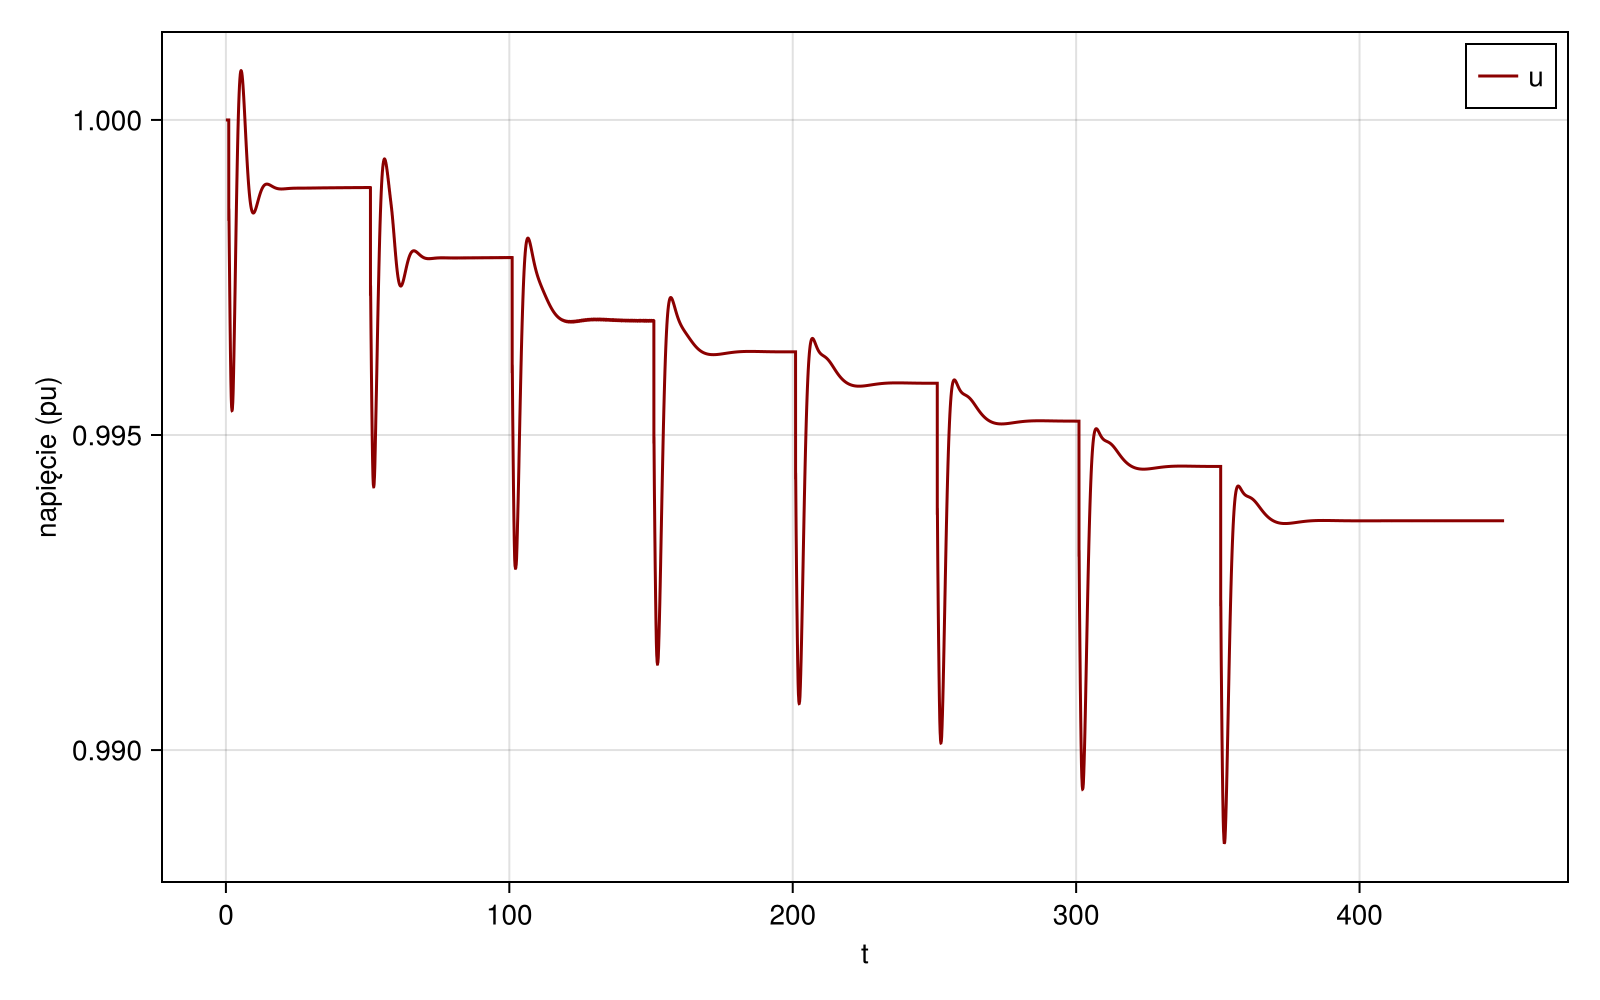

In [53]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="napięcie (pu)")
    
    # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊ω ), color=:darkred, label="ω")
     lines!(ax, sol5, idxs=VIndex(1, :busbar₊u_mag ), color=:darkred, label="u")


    # CairoMakie.xlims!(ax, 1.0, 10.0)
    # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
    
    axislegend(ax, position=:rt)
    fig
end

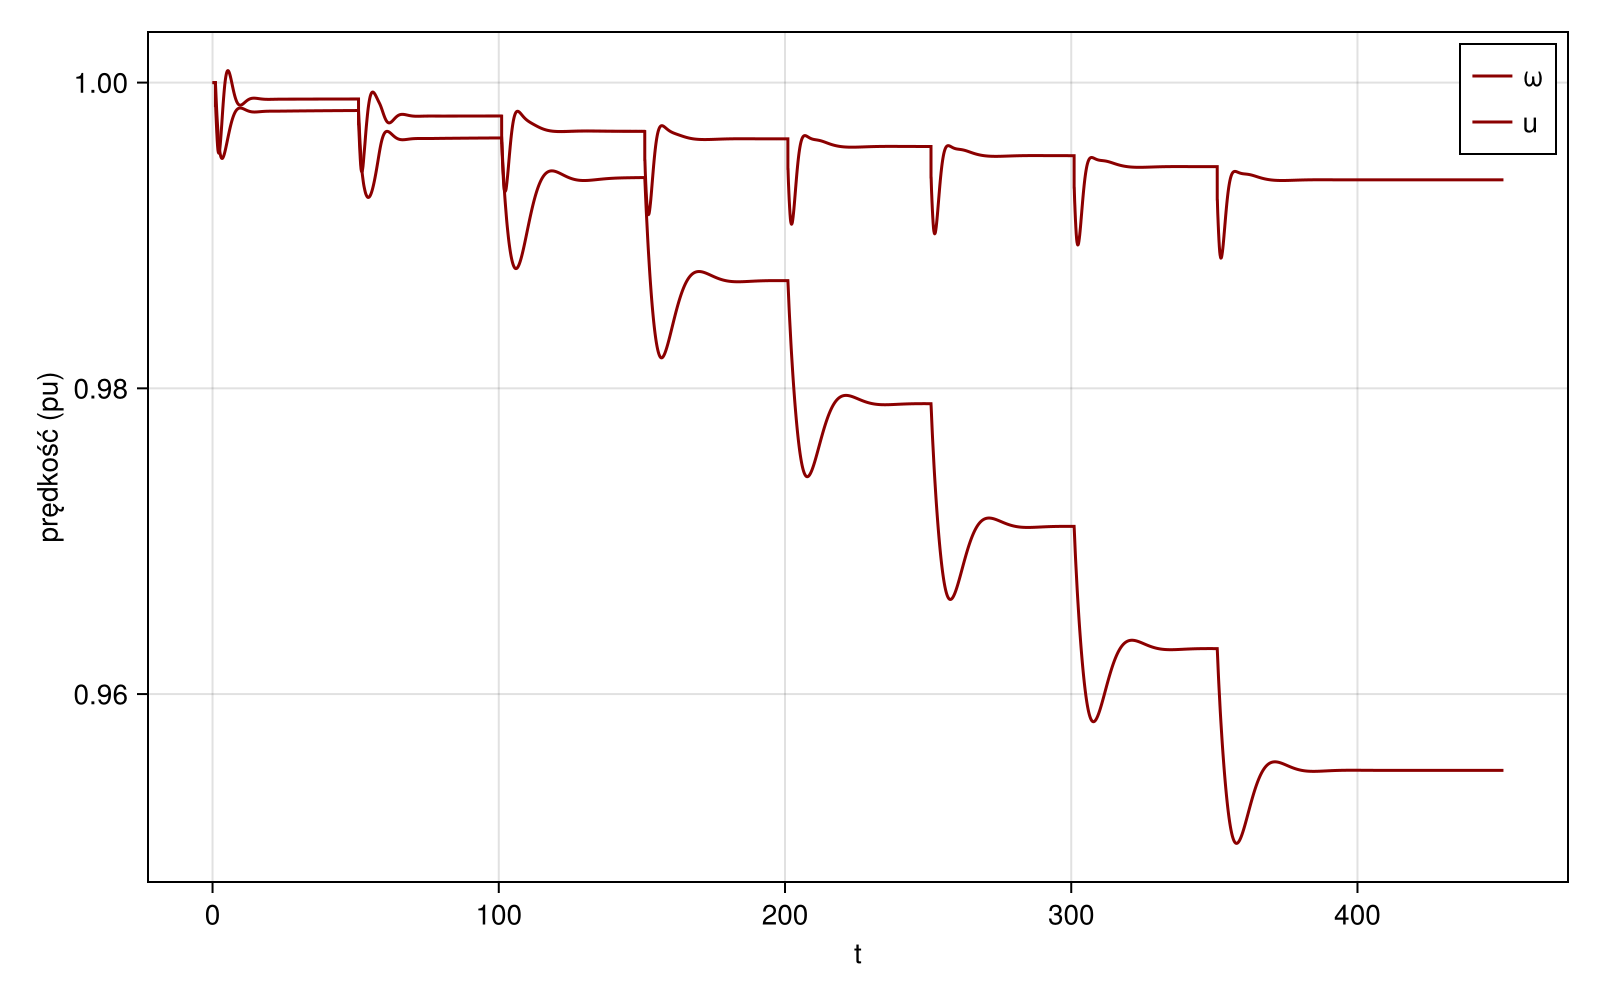

In [46]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="prędkość (pu)")
    
    lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊ω ), color=:darkred, label="ω")


    # CairoMakie.xlims!(ax, 1.0, 10.0)
    # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
    
    axislegend(ax, position=:rt)
    fig
end

In [ ]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="prędkość (pu)")
    
    lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊ω ), color=:darkred, label="ω")

    # CairoMakie.xlims!(ax, 1.0, 10.0)
    # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
    
    axislegend(ax, position=:rt)
    fig
end

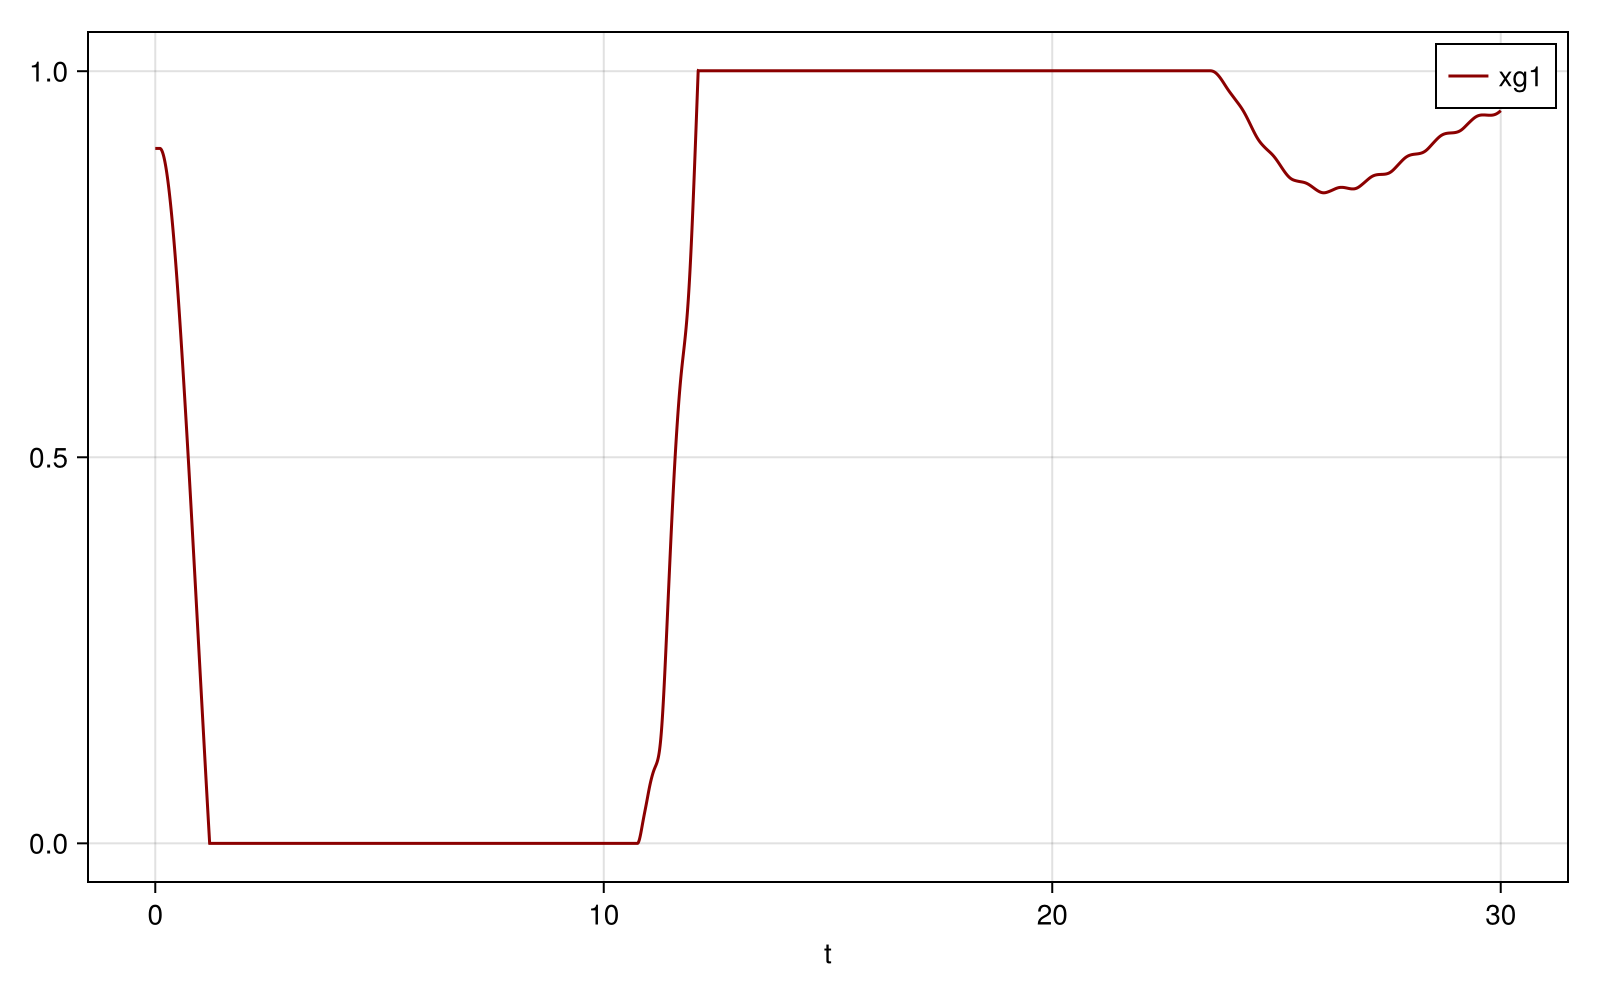

In [9]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="")
    
    lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊gov₊xg1 ), color=:darkred, label="xg1")

    # CairoMakie.xlims!(ax, 1.0, 10.0)
    # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
    
    axislegend(ax, position=:rt)
    fig
end

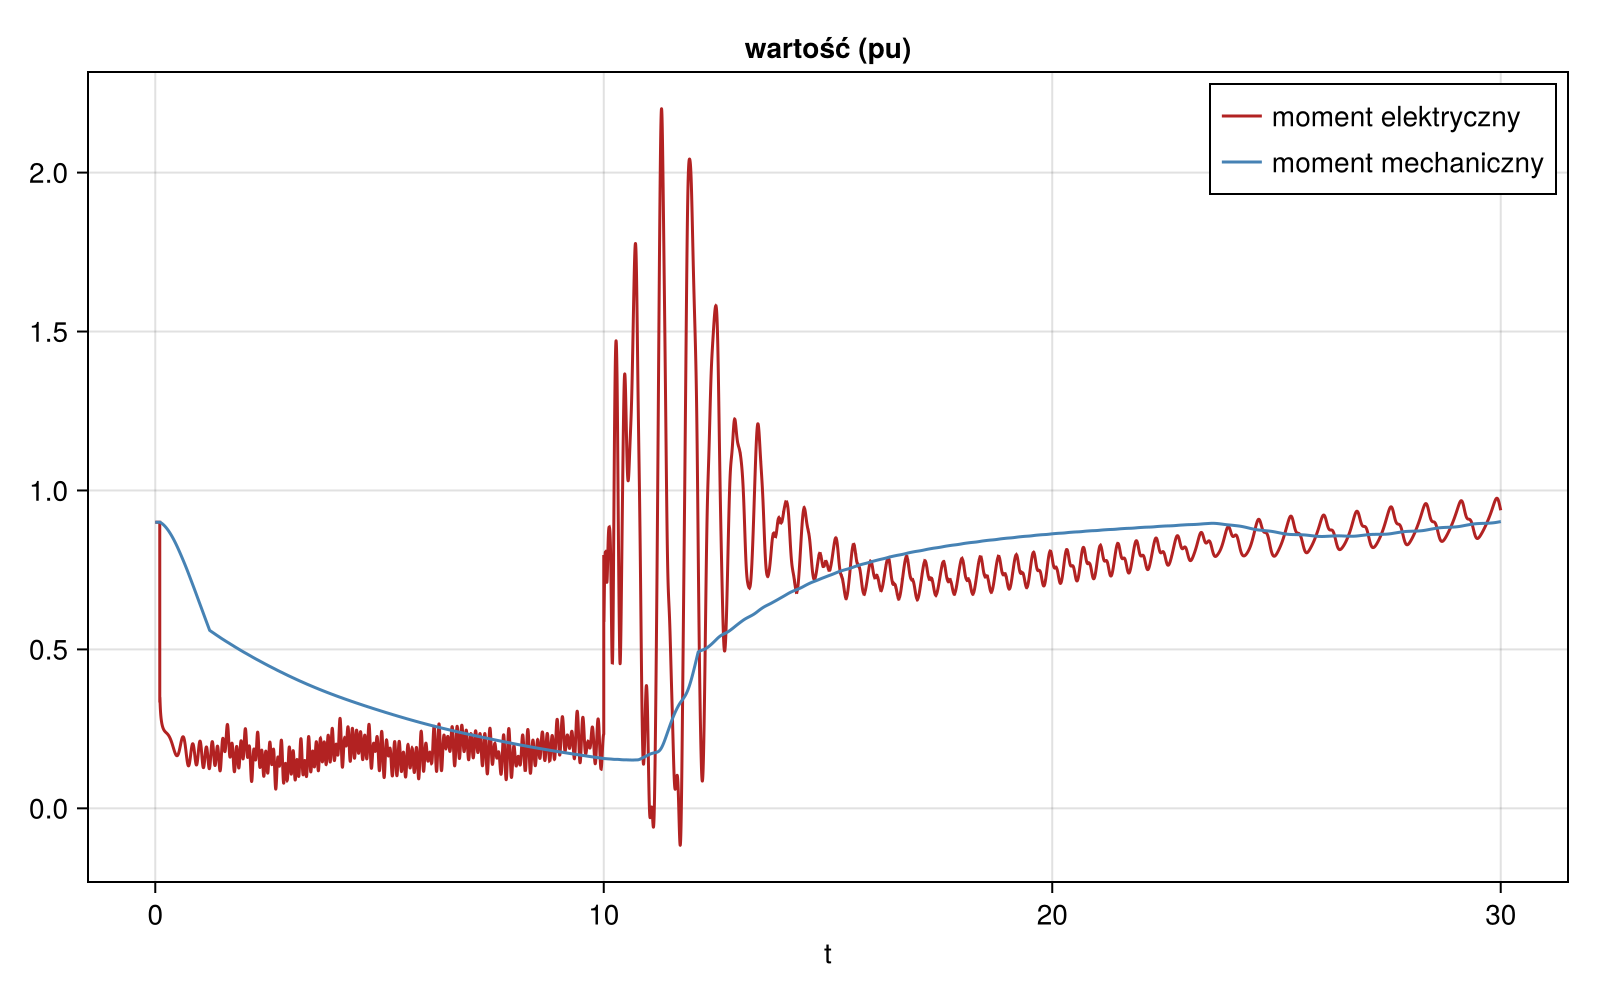

In [10]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="wartość (pu)", xlabel="t", ylabel="")
    
    lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊τ_e ), color=:firebrick, label="moment elektryczny")
    lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊τ_m ), color=:steelblue, label="moment mechaniczny")

    # CairoMakie.xlims!(ax, 1.0, 10.0)
    # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
    
    axislegend(ax, position=:rt)
    fig
end

In [ ]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="prędkość (pu)")
    
    lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊ω ), color=:darkred, label="ω")

    # CairoMakie.xlims!(ax, 1.0, 10.0)
    # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
    
    axislegend(ax, position=:rt)
    fig
end

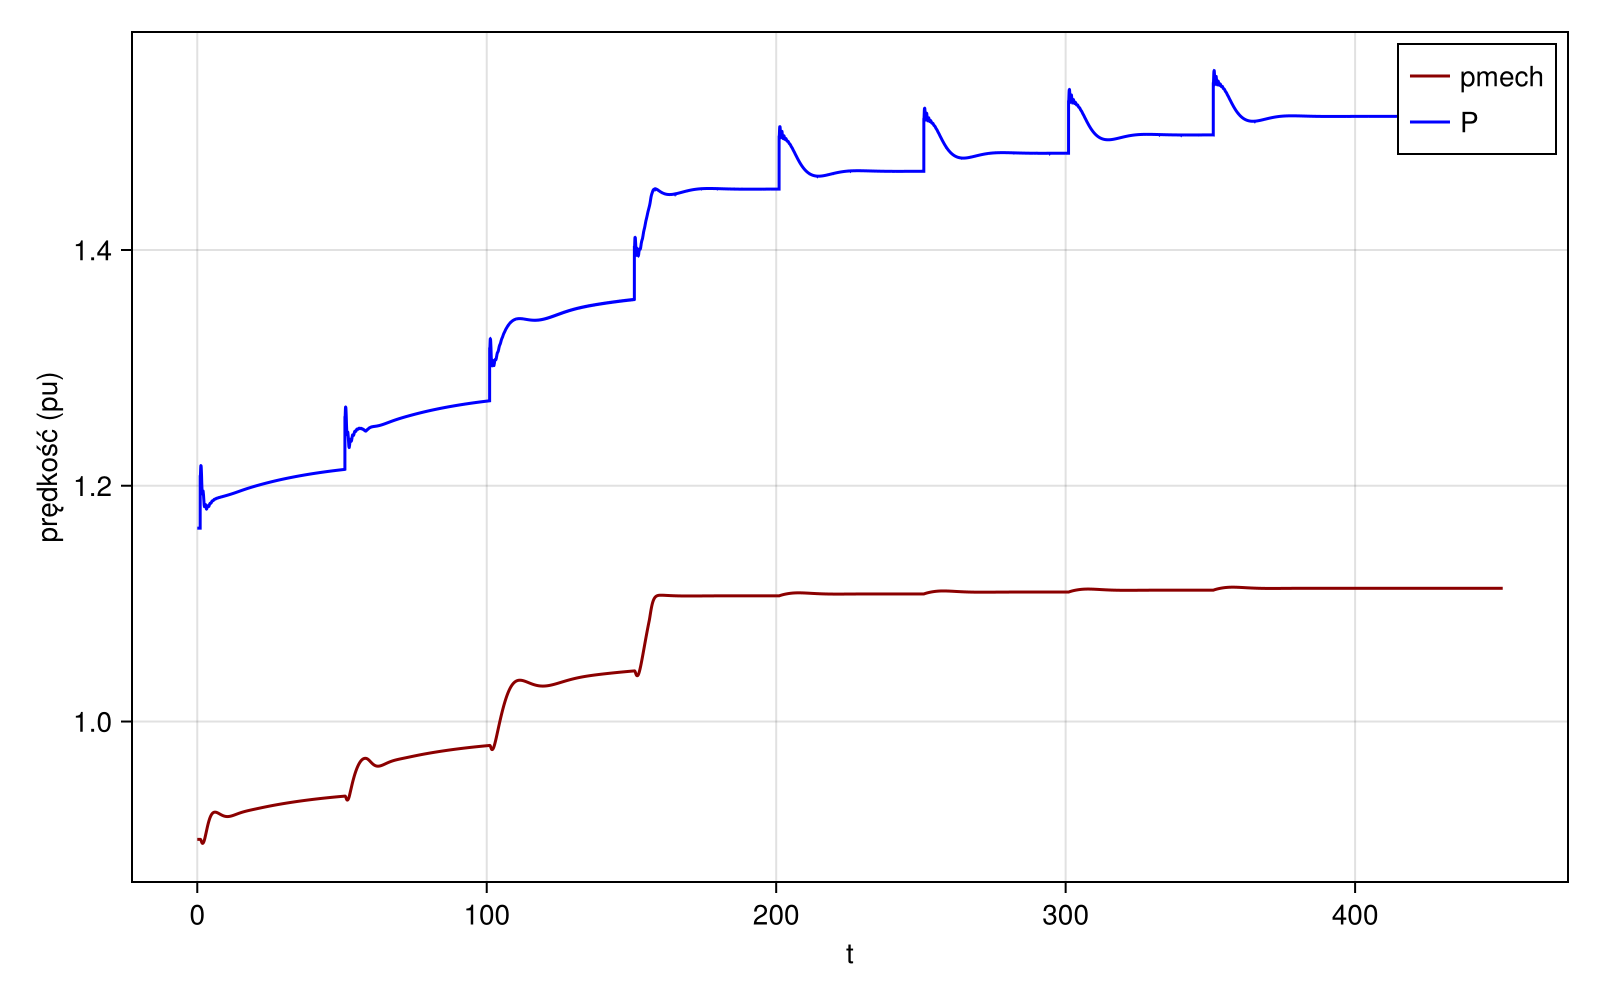

In [43]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="prędkość (pu)")
    
    lines!(ax, sol5, idxs=VIndex(Symbol("404484074_plant"), :gensal₊pmech), color=:darkred, label="pmech")
    lines!(ax, sol5, idxs=VIndex(Symbol("404484074_plant"), :busbar₊P), color=:blue, label="P")
    
    axislegend(ax, position=:rt)
    fig
end

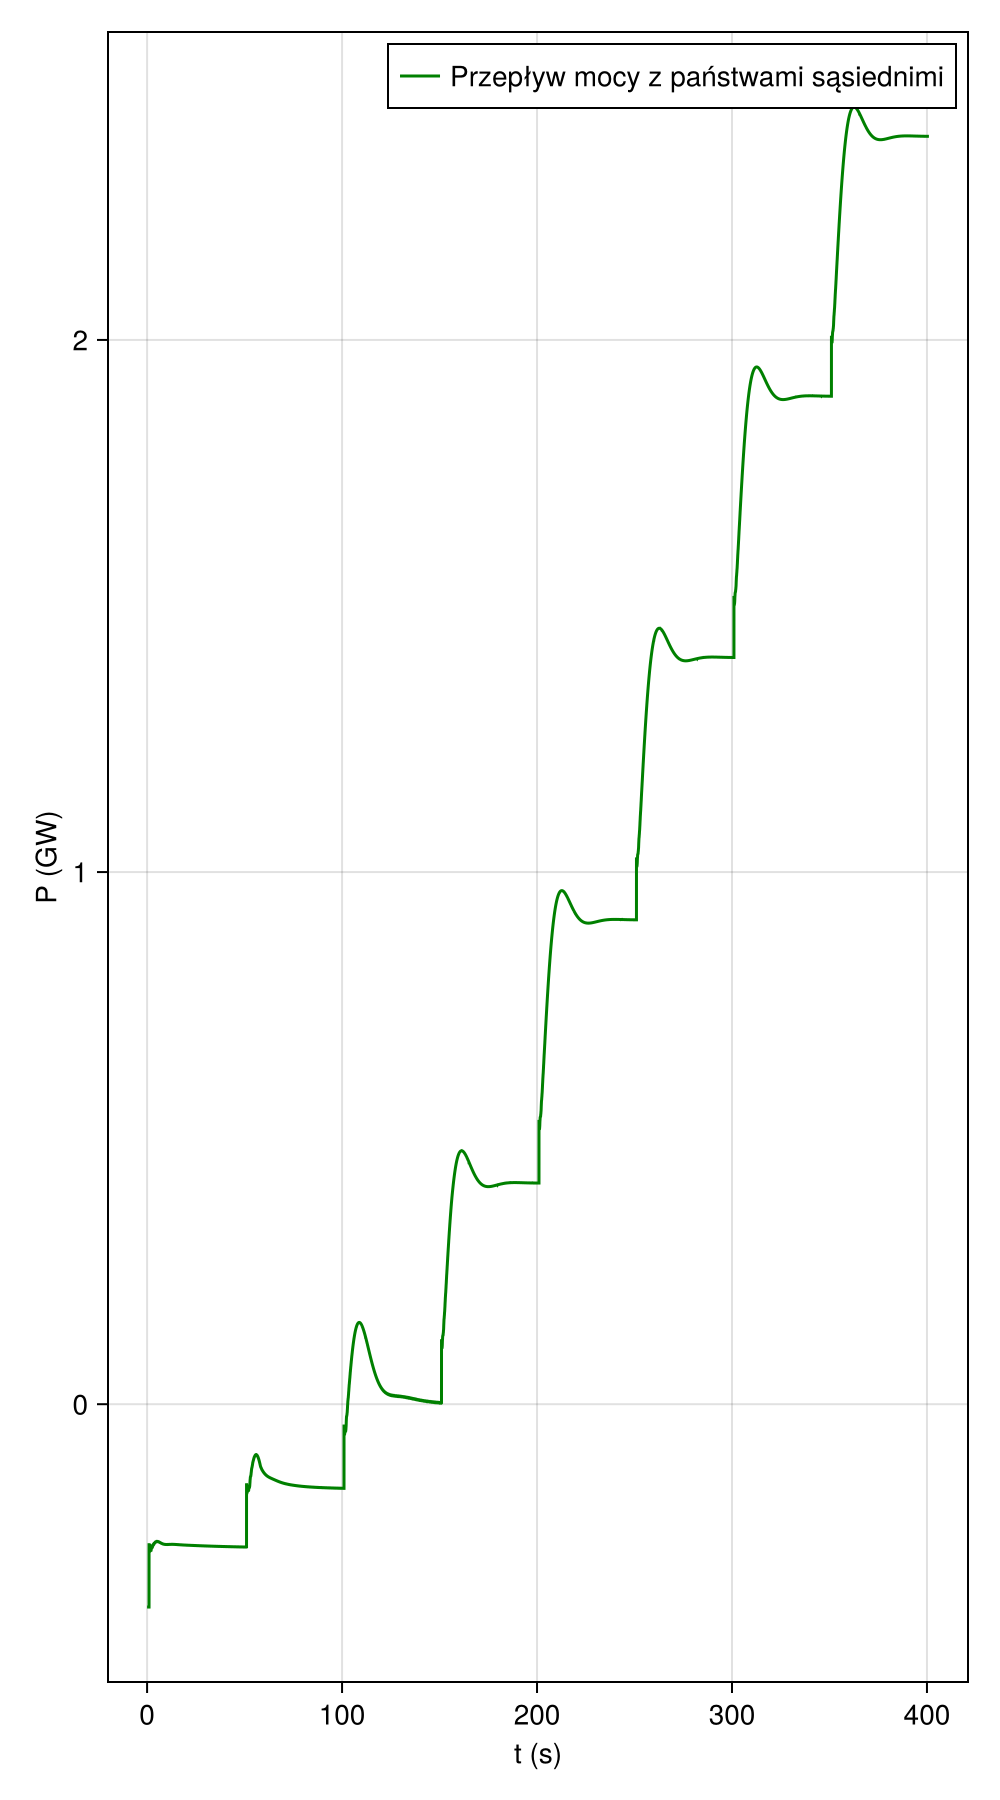

In [5]:
let
    fig = Figure(size = (500, 3 * 300))
    cols = 2

    total_power = zeros(length(sol5.t))
    
    ax = Axis(fig[1, 1], title="", xlabel="t (s)", ylabel="P (GW)")

    total_power .+= sol5(sol5.t, idxs=VIndex(:Germany, :busbar₊P)).u
    total_power .+= sol5(sol5.t, idxs=VIndex(:France, :busbar₊P)).u
    total_power .+= sol5(sol5.t, idxs=VIndex(:Netherlands, :busbar₊P)).u
    
    # Zmiana tutaj: używamy sol5.t (czasy) zamiast całego obiektu sol5
    lines!(ax, sol5.t, total_power, color=:green, label="Przepływ mocy z państwami sąsiednimi")
    
    axislegend(ax, position=:rt)
    fig
end

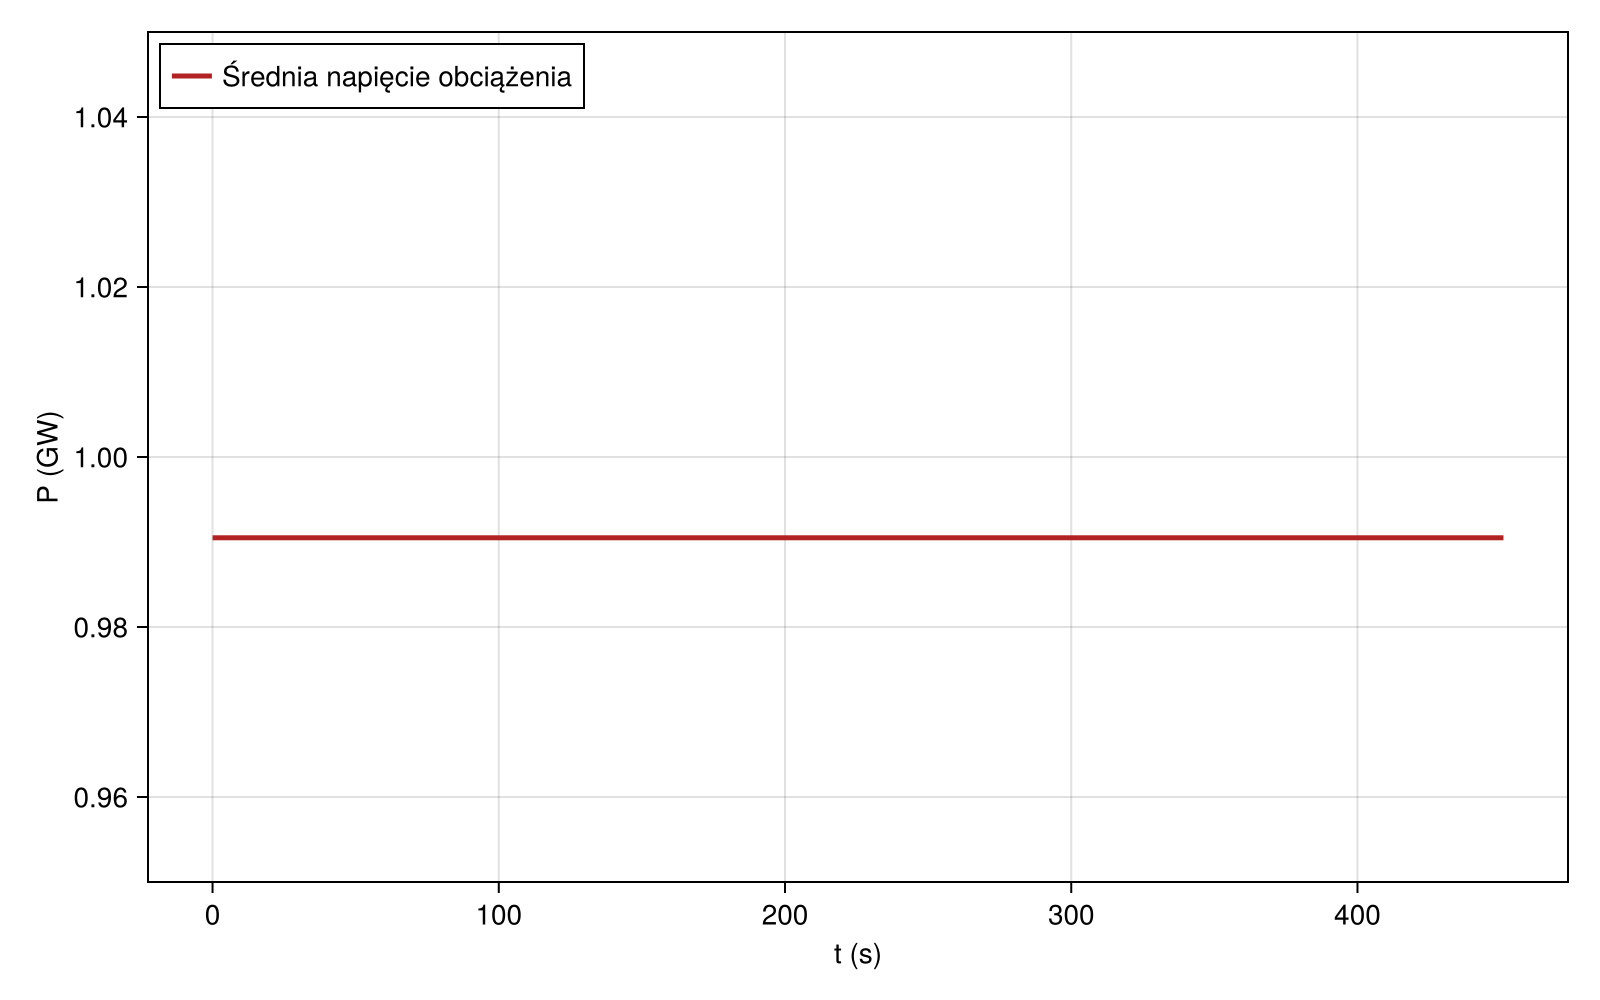

In [45]:
let
    fig = Figure(size = (800, 500))
    ax = Axis(fig[1, 1], title = "", xlabel = "t (s)", ylabel = "P (GW)")

    total1 = zeros(length(sol5.t))
    
    for name in data.nodes     
        parts = split(string(name), "_")

        if length(parts) != 2
            continue
        end
        if parts[2] == "load"
            total1 .= mean(sol5(sol5.t, idxs=VIndex(Symbol(name), :busbar₊u_mag)).u)
        end
    end

    lines!(ax, sol5.t, total1, color = :firebrick, linewidth = 2.5, label = "Średnia napięcie obciążenia")
    axislegend(ax, position=:lt)

    CairoMakie.ylims!(ax, 0.95, 1.05)
    
    fig
end

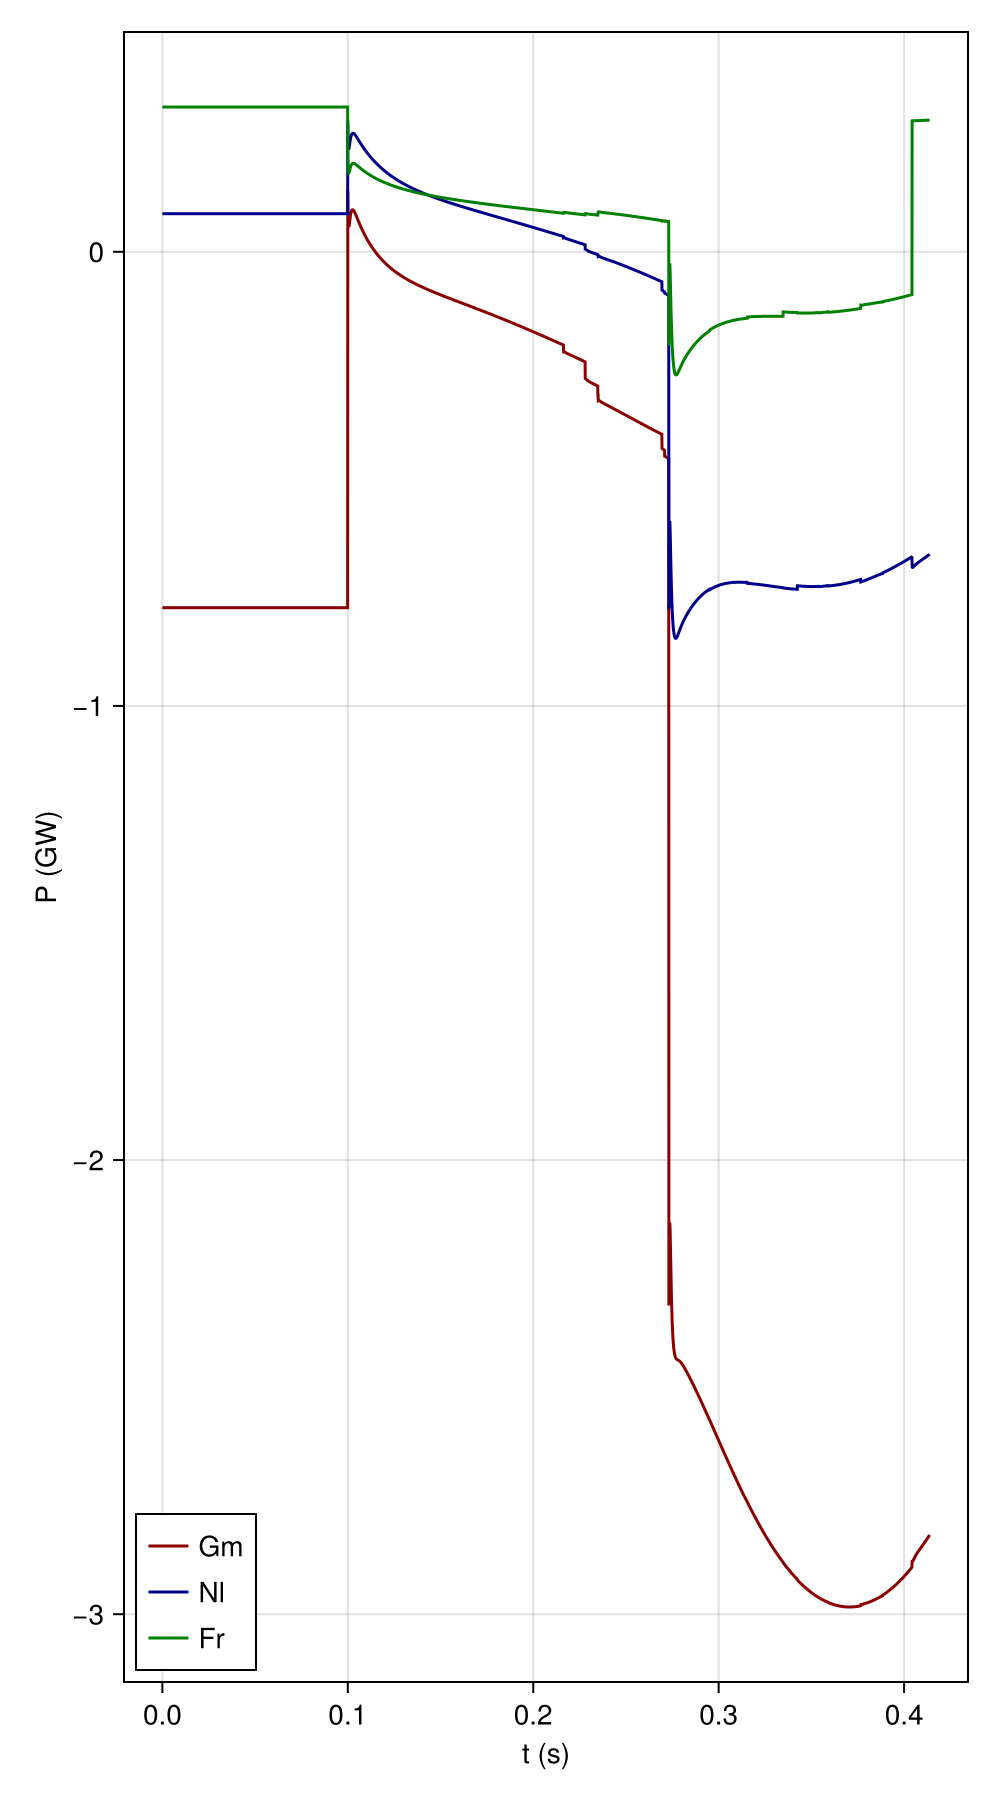

In [14]:
let
    fig = Figure()
    fig = Figure(size = (500, 3 * 300))
    cols = 2
    
    ax = Axis(fig[1, 1], title="", xlabel="t (s)", ylabel="P (GW)")
    
    lines!(ax, sol6, idxs=VIndex(Symbol("Germany"), :busbar₊P), color=:darkred, label="Gm")
    lines!(ax, sol6, idxs=VIndex(Symbol("Netherlands"), :busbar₊P), color=:darkblue, label="Nl")
    lines!(ax, sol6, idxs=VIndex(Symbol("France"), :busbar₊P), color=:green, label="Fr")
    
    axislegend(ax, position=:lb)
    fig
end

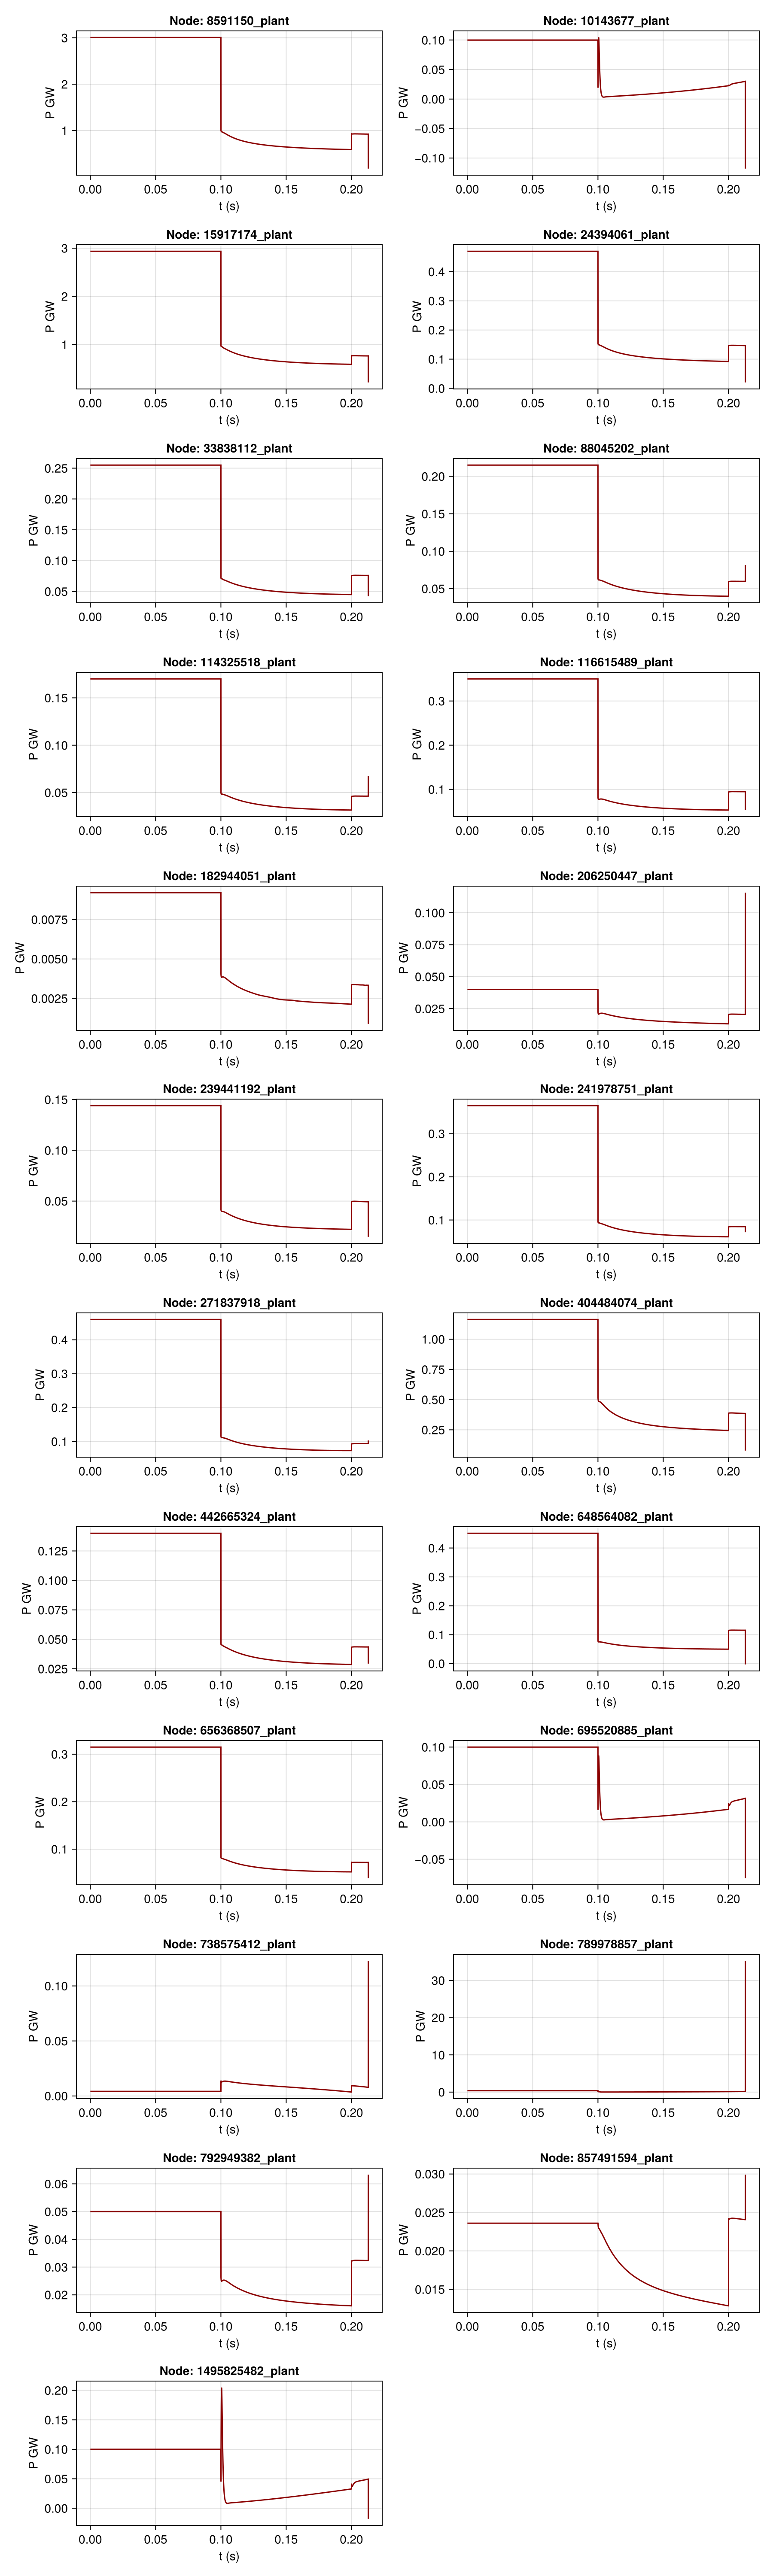

In [5]:
#plants
let
    fig = Figure(size = (900, 10 * 300))
    cols = 2

    i = 1
    for name in data.nodes     
        parts = split(string(name), "_")

        if length(parts) != 2 || parts[2] != "plant"
            continue
        end
        
        row = (i - 1) ÷ cols + 1
        col = (i - 1) % cols + 1
        
        ax = Axis(fig[row, col], title="Node: $(name)", xlabel="t (s)", ylabel="P GW")
        try
        lines!(ax, sol5, idxs=VIndex(Symbol(name), :busbar₊P), color=:darkred)
        lines!(ax, sol5.t, total_load, color = :darkblue, linewidth = 2)
        catch
        end

        i += 1
    end
    
    fig
end

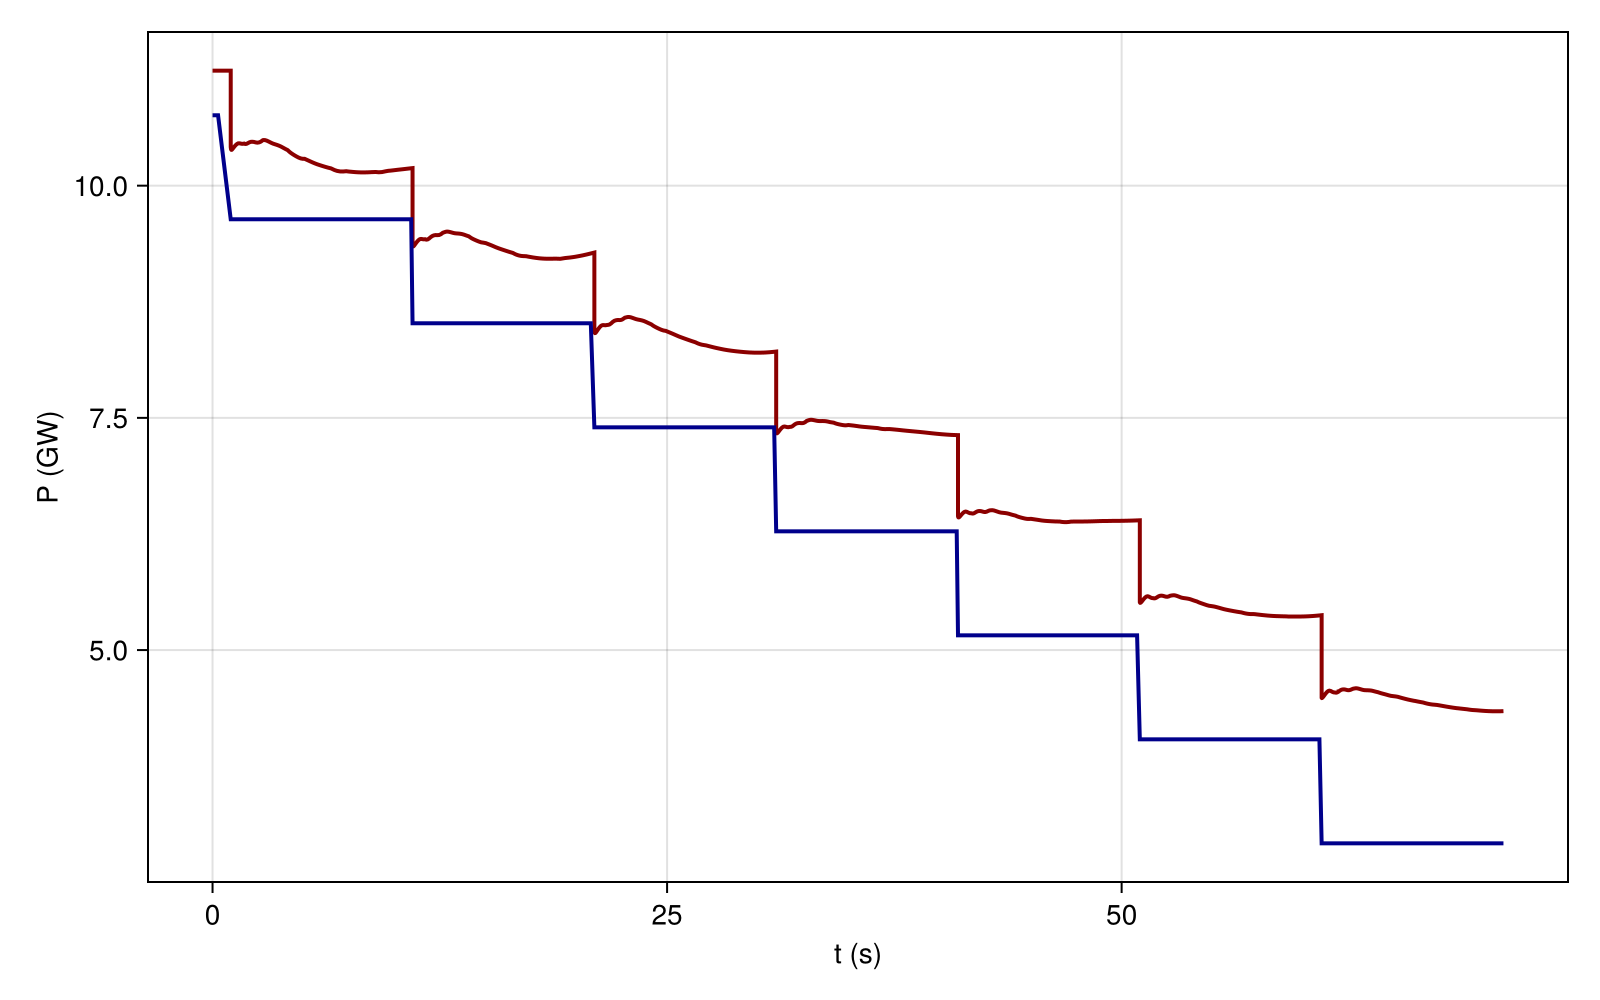

In [37]:
let
    fig = Figure(size = (800, 500))
    ax = Axis(fig[1, 1], title = "", xlabel = "t (s)", ylabel = "P (GW)")

    total_power = zeros(length(sol2.t))
    total_load = zeros(length(sol2.t))
    total_load2 = zeros(length(sol2.t))
    
    for name in data.nodes     
        parts = split(string(name), "_")

        if length(parts) != 2
            continue
        end

        if parts[2] == "plant"
            total_power .+= sol2(sol2.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end

        if parts[2] == "load"
            total_load .-= sol2(sol2.t, idxs=VIndex(Symbol(name), :load₊Pset)).u
            total_load2 .-= sol2(sol2.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end
    end

    lines!(ax, sol2.t, total_power, color = :darkred, linewidth = 2)

    # total_power .+= sol2(sol2.t, idxs=VIndex(Symbol(:Germany), :busbar₊P)).u
    # total_power .+= sol2(sol2.t, idxs=VIndex(Symbol(:France), :busbar₊P)).u
    # total_power .+= sol2(sol2.t, idxs=VIndex(Symbol(:Netherlands), :busbar₊P)).u

    # lines!(ax, sol2.t, total_power, color = :darkred, linewidth = 2, linestyle = :dot)

    lines!(ax, sol2.t, total_load, color = :darkblue, linewidth = 2)
    lines!(ax, sol2.t, total_load2, color = :darkgreen, linewidth = 2)

    fig
end